# Denoising Diffusion Implicit Models (DDIM)

## Complete Beginner's Guide

This notebook introduces **DDIM** - a faster way to generate images from diffusion models. While DDPM requires many steps (often 1000) to generate good images, DDIM can produce similar quality with far fewer steps (50-100).

### What You'll Learn

1. **The Problem with DDPM**: Why 1000 steps is slow
2. **DDIM Solution**: A deterministic (or partially stochastic) sampling method
3. **The eta (η) Parameter**: Control the randomness
4. **HuggingFace Schedulers**: Using pre-built DDPM and DDIM schedulers
5. **Implementing DDIM from Scratch**: Understanding the math
6. **Triangular Noise**: A training improvement

### Prerequisites
- Basic Python knowledge
- Understanding of DDPM from previous notebooks (helpful but not required)

### DDPM vs DDIM Quick Comparison

```
DDPM (Denoising Diffusion Probabilistic Models):
- Stochastic (random) sampling
- Requires ~1000 steps for good quality
- Each run with same starting noise → different image

DDIM (Denoising Diffusion Implicit Models):
- Can be deterministic (eta=0) or stochastic (eta=1)
- Works well with 50-200 steps
- When deterministic: same starting noise → same image
```

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** DDIM sampling itself is fast; training the model needs a GPU. **Runtime &rarr; GPU**.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [8]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`20_DDIM_explained.ipynb`), unchanged.*

---

---
## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder / published on GitHub Pages) at **full width**,
auto-fitted to their content height (no empty space below). Run the next cell once,
then run any 🎮 cell. Every visualization follows the same grammar: **numbered chips replay
their part of the story**, a *live card* narrates the current instant with real schedule numbers,
a *"How to read it"* line decodes the visual encoding, and the matching code lines light up in sync.

In [9]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

---
## Theoretical Background: DDPM vs DDIM

Before diving into the code, let's understand the **mathematical foundations** of both DDPM and DDIM, and see exactly how DDIM achieves faster sampling.

---

### Quick Notation Reference

| Symbol | Name | Meaning |
|--------|------|---------|
| x₀ | Original image | The clean image we want to generate |
| xₜ | Noisy image | Image at timestep t (more noise as t increases) |
| ε | Epsilon | Gaussian noise ~ N(0, I) |
| ε_θ | Model prediction | Neural network's prediction of the noise |
| αₜ | Alpha | Signal retention at step t: αₜ = 1 - βₜ |
| ᾱₜ | Alpha bar | Cumulative signal: ᾱₜ = α₁ × α₂ × ... × αₜ |
| βₜ | Beta | Noise variance added at step t |
| β̄ₜ | Beta bar | 1 - ᾱₜ (cumulative noise) |
| σₜ | Sigma | Noise level for sampling step |
| η | Eta | DDIM's stochasticity parameter (0 to 1) |

---

### The Forward Diffusion Process (Same for Both!)

Both DDPM and DDIM use the **same forward process** to add noise:

```
Forward Diffusion Formula:
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│     xₜ = √(ᾱₜ) · x₀ + √(1 - ᾱₜ) · ε                        │
│           ────────     ────────────                         │
│           signal        noise                               │
│           part          part                                │
│                                                             │
│     where ε ~ N(0, I) is random Gaussian noise              │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

**Key insight**: Given a clean image x₀ and a timestep t, we can directly compute xₜ without going through intermediate steps. This is because the noise accumulation is a simple weighted sum.

```
Visualization of Forward Process:

t=0          t=250        t=500        t=750        t=999
x₀           x₂₅₀         x₅₀₀         x₇₅₀         x₉₉₉
┌────┐       ┌────┐       ┌────┐       ┌────┐       ┌────┐
│👕  │  ──►  │👕░ │  ──►  │░░░ │  ──►  │░░░ │  ──►  │░░░░│
│    │       │ ░  │       │░👕░│       │░░░░│       │░░░░│
└────┘       └────┘       └────┘       └────┘       └────┘
100% signal  75% signal   25% signal   5% signal   ~0% signal
0% noise     25% noise    75% noise    95% noise   100% noise

ᾱₜ ≈ 1.0     ᾱₜ ≈ 0.56    ᾱₜ ≈ 0.06    ᾱₜ ≈ 0.002   ᾱₜ ≈ 0.0
```

---

### The Reverse Process: Where DDPM and DDIM Differ!

The **reverse process** is where DDPM and DDIM diverge. Both aim to go from xₜ back to xₜ₋₁ (and eventually x₀), but they do it differently.

**The Core Problem:**
Given xₜ (noisy image) and the model's noise prediction ε_θ(xₜ, t), how do we compute xₜ₋₁?

Both methods first estimate x₀ from xₜ:

```
Predicting x₀ from xₜ (Same for Both):
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│            xₜ - √(1 - ᾱₜ) · ε_θ(xₜ, t)                      │
│     x̂₀ = ─────────────────────────────                      │
│                    √(ᾱₜ)                                    │
│                                                             │
│     This is just rearranging the forward formula!           │
│                                                             │
└─────────────────────────────────────────────────────────────┘

Derivation:
  xₜ = √(ᾱₜ) · x₀ + √(1-ᾱₜ) · ε
  xₜ - √(1-ᾱₜ) · ε = √(ᾱₜ) · x₀
  x₀ = (xₜ - √(1-ᾱₜ) · ε) / √(ᾱₜ)
```

Now comes the key difference: **How do we get from this predicted x₀ to xₜ₋₁?**

In [10]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/1_ddim_theory_foundations.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Theory foundations: the DDPM vs DDIM setup, laid side by side.
# ============================================================================
show_viz("interactive_viz/1_ddim_theory_foundations.html", height="700px")

### 🎮 Interactive: the forward process — two faucets, one formula

Before going further, build intuition for the formula above. Two "faucets" pour the clean image x₀ and a
fixed noise field ε into the mix xₜ — and the **faucet widths *are* the coefficients** √ᾱₜ and √(1−ᾱₜ),
recomputed live from this notebook's real schedule (β: 0.0001→0.01) as you drag **t**. A purple marker rides
the coefficient chart, and a dashed line marks the exact **crossover timestep where ᾱ = 0.5** (equal mix).

**Things to try:** press each numbered chip — they *replay* their segment (① Meet the pieces → ④ Wipe-out);
watch the live SNR readout in dB flip sign at the crossover; drag t slowly through 0→40 and confirm you can't
even see the noise yet.

In [11]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_forward_diffusion.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Faucet widths = mixing coefficients; live marker on the schedule chart; chips replay.
# ============================================================================
show_viz("interactive_viz/ddim_forward_diffusion.html", height="860px")

---

## DDPM Reverse Process (Review)

DDPM uses a **stochastic** (random) reverse process derived from Bayesian inference.

### The DDPM Update Rule

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        DDPM UPDATE FORMULA                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│                    1                    βₜ                                  │
│     xₜ₋₁ = ────────── (xₜ - ────────────── · ε_θ(xₜ,t)) + σₜ · z           │
│              √(αₜ)         √(1 - ᾱₜ)                                        │
│                                                                             │
│     where:                                                                  │
│       • z ~ N(0, I) is fresh random noise (independent of ε_θ)             │
│       • σₜ = √(βₜ) is the noise standard deviation                         │
│       • This noise z is MANDATORY in DDPM (except at t=0)                  │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Alternative Form (Using x̂₀ Prediction)

DDPM can also be written in terms of predicted x₀:

```
Step 1: Predict clean image
        x̂₀ = (xₜ - √(1-ᾱₜ) · ε_θ) / √(ᾱₜ)

Step 2: Interpolate between xₜ and x̂₀, then add noise
                   √(ᾱₜ₋₁) · βₜ           √(αₜ) · (1-ᾱₜ₋₁)
        xₜ₋₁ = ─────────────────── · x̂₀ + ─────────────────── · xₜ + σₜ · z
                    1 - ᾱₜ                      1 - ᾱₜ
```

### Why DDPM Needs All 1000 Steps

**The Problem**: DDPM's derivation assumes you take **small steps** (t → t-1). The math relies on:

1. **Gaussian approximation**: Each step is a small perturbation
2. **Variance accumulation**: Noise adds up correctly only with consecutive steps
3. **Markov chain**: Each step only depends on the previous step

```
DDPM Markov Chain:
x_999 → x_998 → x_997 → ... → x_1 → x_0
  ↓       ↓       ↓            ↓     ↓
 z₉₉₉    z₉₉₈    z₉₉₇         z₁   (no z)

Each transition requires its own random noise z!
If you skip steps, the noise doesn't accumulate correctly.
```

**The Consequence**: If you try to skip steps in DDPM (e.g., t → t-10), the variance calculations break down, and you get poor quality images.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/2_ddpm_reverse_review.html
# at full width, sized to fit the visualization (setup cell near the top required).
# DDPM reverse process, reviewed one stochastic step at a time.
# ============================================================================
show_viz("interactive_viz/2_ddpm_reverse_review.html", height="700px")

---

## DDIM Reverse Process: The Key Innovation

DDIM (Denoising Diffusion Implicit Models) introduces a **non-Markovian** generalization of the diffusion process. The key insight is that we can define a different reverse process that:

1. Still matches the same forward process (same training objective!)
2. Allows for **deterministic** sampling when η = 0
3. Can **skip timesteps** without breaking the math

### The DDIM Update Rule

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        DDIM UPDATE FORMULA                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│     xₜ₋₁ = √(ᾱₜ₋₁) · x̂₀ + √(1 - ᾱₜ₋₁ - σₜ²) · ε_θ(xₜ,t) + σₜ · z         │
│             ──────────     ─────────────────────────────     ─────          │
│             "direction      "direction pointing to xₜ"     stochastic      │
│             to x₀"                                          noise          │
│                                                                             │
│     where:                                                                  │
│       • x̂₀ = (xₜ - √(1-ᾱₜ) · ε_θ) / √(ᾱₜ)  (predicted clean image)        │
│       • σₜ = η · √[(1-ᾱₜ₋₁)/(1-ᾱₜ)] · √[1 - ᾱₜ/ᾱₜ₋₁]  (noise level)       │
│       • z ~ N(0, I) is random noise (ONLY if σₜ > 0)                       │
│       • η ∈ [0, 1] controls stochasticity                                  │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Understanding Each Term

Let's break down what each term in the DDIM formula does:

```
xₜ₋₁ = √(ᾱₜ₋₁) · x̂₀  +  √(1 - ᾱₜ₋₁ - σₜ²) · ε_θ  +  σₜ · z
       ───────────────   ───────────────────────    ────────
            Term 1              Term 2               Term 3


Term 1: √(ᾱₜ₋₁) · x̂₀
┌──────────────────────────────────────────────────────────────────┐
│ This term "aims toward" the predicted clean image x̂₀             │
│                                                                  │
│ - √(ᾱₜ₋₁) is how much signal should be at timestep t-1          │
│ - x̂₀ is our best guess of the clean image                       │
│ - Together: scale x̂₀ to the right signal level for t-1          │
└──────────────────────────────────────────────────────────────────┘

Term 2: √(1 - ᾱₜ₋₁ - σₜ²) · ε_θ
┌──────────────────────────────────────────────────────────────────┐
│ This term preserves the "noise direction" from the current step  │
│                                                                  │
│ - ε_θ is the model's predicted noise direction                   │
│ - The coefficient ensures total variance is correct              │
│ - Think of it as: "keep some predictable noise"                  │
└──────────────────────────────────────────────────────────────────┘

Term 3: σₜ · z
┌──────────────────────────────────────────────────────────────────┐
│ This term adds FRESH random noise                                │
│                                                                  │
│ - σₜ is controlled by η (eta parameter)                         │
│ - When η = 0: σₜ = 0, no fresh noise → DETERMINISTIC             │
│ - When η = 1: σₜ matches DDPM → STOCHASTIC                       │
│ - z ~ N(0,I) is independent random noise                         │
└──────────────────────────────────────────────────────────────────┘
```

### The σₜ Formula (Variance Control)

```
σₜ = η · √[(1 - ᾱₜ₋₁) / (1 - ᾱₜ)] · √[1 - ᾱₜ / ᾱₜ₋₁]
     ▲   ─────────────────────────────────────────────
     │              Base variance term
     │              (matches DDPM when η = 1)
     │
   Controls interpolation:
     η = 0: σₜ = 0 (no random noise)
     η = 1: σₜ matches DDPM variance
```

This formula is designed so that:
- The **total variance** of xₜ₋₁ is correct regardless of η
- When η = 1, it reduces to exactly DDPM
- When η = 0, all randomness is removed

### Why DDIM Can Skip Steps

The key mathematical insight: DDIM's formula only depends on:
- The **current** noisy image xₜ
- The **cumulative** noise levels ᾱₜ and ᾱₜ₋₁

It does **NOT** depend on the intermediate steps! This means we can go directly from t to any earlier timestep s < t:

```
DDPM (must go step by step):
x₉₉₉ → x₉₉₈ → x₉₉₇ → x₉₉₆ → ... → x₁ → x₀
  ↓       ↓       ↓       ↓            ↓
 z₉₉₉    z₉₉₈    z₉₉₇    z₉₉₆         z₁

Each step needs its own noise z. Skipping breaks the variance.


DDIM (can skip freely):
x₉₉₀ ─────────────────► x₉₈₀ ─────────────────► x₉₇₀ → ... → x₀
                │                       │
        (uses ᾱ₉₉₀ and ᾱ₉₈₀)   (uses ᾱ₉₈₀ and ᾱ₉₇₀)

Only needs ᾱ values for the timesteps we actually use!
The formula correctly handles any jump size.
```

In [12]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/3_ddim_reverse_innovation.html
# at full width, sized to fit the visualization (setup cell near the top required).
# DDIM reverse process: the key non-Markovian innovation, unpacked.
# ============================================================================
show_viz("interactive_viz/3_ddim_reverse_innovation.html", height="700px")

![ddim.png](https://github.com/shammun/shammunul-fastai-notes/blob/main/notebooks/ddpm_ddim.png?raw=1)

![ddim.png](https://github.com/shammun/shammunul-fastai-notes/blob/main/notebooks/ddim.png?raw=1)

![ddim.png](https://github.com/shammun/shammunul-fastai-notes/blob/main/notebooks/ddim_sigma_t.png?raw=1)

---

## Side-by-Side Comparison: DDPM vs DDIM

Now let's put everything together and see the exact differences:

### Update Formulas Compared

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    DDPM vs DDIM: THE KEY EQUATIONS                          │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  BOTH start with predicting x₀:                                             │
│                                                                             │
│          xₜ - √(1-ᾱₜ) · ε_θ                                                 │
│    x̂₀ = ─────────────────────                                               │
│               √(ᾱₜ)                                                         │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  DDPM Update:                                                               │
│  ───────────                                                                │
│            1          βₜ                                                    │
│    xₜ₋₁ = ─── (xₜ - ────── · ε_θ) + √(βₜ) · z                              │
│           √αₜ       √(1-ᾱₜ)                                                 │
│                                                                             │
│    - z is ALWAYS added (except at t=0)                                      │
│    - Cannot skip steps                                                      │
│    - Each step adds fresh random noise                                      │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  DDIM Update:                                                               │
│  ───────────                                                                │
│    xₜ₋₁ = √(ᾱₜ₋₁) · x̂₀ + √(1-ᾱₜ₋₁-σₜ²) · ε_θ + σₜ · z                     │
│            ──────────    ────────────────────    ─────                      │
│            toward x₀     predicted noise         random                     │
│                          direction               noise                      │
│                                                                             │
│    - σₜ = η · √[(1-ᾱₜ₋₁)/(1-ᾱₜ)] · √[1-ᾱₜ/ᾱₜ₋₁]                           │
│    - When η=0: σₜ=0, no random noise → deterministic                        │
│    - When η=1: matches DDPM variance                                        │
│    - Can skip to any timestep (not just t-1)                                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Feature Comparison Table

| Feature | DDPM | DDIM |
|---------|------|------|
| **Process Type** | Markovian (each step depends only on previous) | Non-Markovian (can jump across timesteps) |
| **Randomness** | Always stochastic (z added every step) | Controllable via η parameter |
| **Minimum Steps** | ~1000 for good quality | 50-200 for good quality |
| **Same Noise → Same Image?** | No (different each run) | Yes when η=0 |
| **Training** | Same | Same (no retraining needed!) |
| **Update Formula** | Based on single-step Gaussian transition | Based on direct x₀ prediction |
| **Variance** | Fixed by noise schedule | Interpolated by η |

### Visual: The Two Sampling Strategies

```
DDPM Sampling (Stochastic Random Walk):
┌──────────────────────────────────────────────────────────────────────────┐
│                                                                          │
│  Start: x₉₉₉ (pure noise)                                               │
│         │                                                                │
│         ├──z₉₉₉──► x₉₉₈  (random step, adds noise z)                    │
│         │          │                                                     │
│         │          ├──z₉₉₈──► x₉₉₇                                      │
│         │          │          │                                          │
│         │          │          ├──z₉₉₇──► ...                            │
│         │          │          │                                          │
│         ▼          ▼          ▼                                          │
│                                                                          │
│  Path is a RANDOM WALK - same starting point, different paths each run  │
│                                                                          │
│  Like: Drunk person stumbling home, always ends up somewhere different  │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘

DDIM Sampling (Deterministic when η=0):
┌──────────────────────────────────────────────────────────────────────────┐
│                                                                          │
│  Start: x₉₉₀ (pure noise)                                               │
│         │                                                                │
│         ├─────────────────► x₉₈₀  (direct jump, no random noise)        │
│         │                   │                                            │
│         │                   ├─────────────────► x₉₇₀                    │
│         │                   │                   │                        │
│         │                   │                   ├─────────────────► ...  │
│         ▼                   ▼                   ▼                        │
│                                                                          │
│  Path is DETERMINISTIC - same starting point, same path every time      │
│                                                                          │
│  Like: GPS navigation - always takes the exact same route               │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
```

### The η (Eta) Parameter Explained

The eta parameter is the key innovation of DDIM that controls the trade-off between:
- **Determinism** (reproducibility, same image every time)
- **Stochasticity** (variety, different images from same starting noise)

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         THE ETA (η) PARAMETER                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  η controls the amount of random noise added at each step:                  │
│                                                                             │
│      σₜ = η · √[(1-ᾱₜ₋₁)/(1-ᾱₜ)] · √[1-ᾱₜ/ᾱₜ₋₁]                           │
│           ▲                                                                 │
│           │                                                                 │
│           └── When η = 0: σₜ = 0 (no random noise)                         │
│               When η = 1: σₜ = DDPM variance (full random noise)           │
│               When 0 < η < 1: Interpolation between the two               │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  η = 0 (FULLY DETERMINISTIC)                                               │
│  ────────────────────────────                                               │
│                                                                             │
│  xₜ₋₁ = √(ᾱₜ₋₁) · x̂₀ + √(1-ᾱₜ₋₁) · ε_θ                                    │
│                          ▲                                                  │
│                          │                                                  │
│                    No random z term!                                        │
│                                                                             │
│  Properties:                                                                │
│  • Same starting noise → exact same final image                            │
│  • Reproducible results                                                     │
│  • Good for: interpolation, editing, consistent outputs                    │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  η = 1 (EQUIVALENT TO DDPM)                                                │
│  ──────────────────────────                                                 │
│                                                                             │
│  xₜ₋₁ = √(ᾱₜ₋₁) · x̂₀ + √(1-ᾱₜ₋₁-σₜ²) · ε_θ + σₜ · z                       │
│                                                    ▲                        │
│                                                    │                        │
│                                              Full DDPM noise               │
│                                                                             │
│  Properties:                                                                │
│  • Same starting noise → different final image each run                    │
│  • More variety in outputs                                                  │
│  • Mathematically equivalent to DDPM sampling                              │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  0 < η < 1 (INTERPOLATION)                                                 │
│  ──────────────────────────                                                 │
│                                                                             │
│  Properties:                                                                │
│  • Partial randomness                                                       │
│  • Same starting noise → slightly different images                         │
│  • Balance between reproducibility and variety                             │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Practical Impact of η

```
η = 0:
┌────┐     ┌────┐     ┌────┐
│ 👕 │  →  │ 👕 │  →  │ 👕 │   (Always same output!)
└────┘     └────┘     └────┘
 Run 1      Run 2      Run 3

η = 1:
┌────┐     ┌────┐     ┌────┐
│ 👕 │  →  │ 👖 │  →  │ 👟 │   (Different outputs!)
└────┘     └────┘     └────┘
 Run 1      Run 2      Run 3

Starting from the SAME initial noise tensor!
```

### Summary: Why DDIM is Faster

1. **DDIM doesn't accumulate random noise** → No variance explosion from skipping
2. **Uses cumulative ᾱ values** → Works for any timestep gap
3. **Deterministic option** → Predictable behavior with fewer steps
4. **Same training** → No need to retrain the model!

In [13]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/4_ddim_vs_ddpm_comparison.html
# at full width, sized to fit the visualization (setup cell near the top required).
# DDPM vs DDIM update rules, put side by side.
# ============================================================================
show_viz("interactive_viz/4_ddim_vs_ddpm_comparison.html", height="700px")

### 🎮 Interactive: DDPM vs DDIM — same start, two ways home

One shared arena instead of two panels — because the punchline is that **both walkers leave the *same*
pinned x_T** with the *same* model. The orange DDPM walker staggers home (watch the flashing fresh-`z`
kicks and its climbing z-draw counter); the teal DDIM walker glides on one smooth curve. Chip ④ freezes
mid-flight and dissects one step of each into arrows — the σ·z arrow simply doesn't exist for DDIM.
Chip ⑤ sends a purple runner hopping bead-to-bead along the DDIM curve while a red ✗ shows a DDPM
hop landing off-path.

**Things to try:** replay ② and ③ back-to-back and compare the trails; read the live race card's
"fresh z draws" line — 999 vs 0 is the whole story; on ⑤, note DDIM finishes with 10 hops.

In [14]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_ddpm_vs_ddim_paths.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ONE shared arena: pinned x_T, live walkers, z-kick flashes, hop runner, step dissection.
# ============================================================================
show_viz("interactive_viz/ddim_ddpm_vs_ddim_paths.html", height="940px")

---
## Imports

In [15]:
# Standard Python libraries
import pickle,gzip,math,os,time,shutil,torch,random,logging
import fastcore.all as fc  # Fast.ai utilities
import matplotlib as mpl   # Plotting configuration
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting
from collections.abc import Mapping
from pathlib import Path
from functools import partial

# FastCore utilities
from fastcore.foundation import L

# PyTorch and torchvision
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler

# miniai - Fast.ai's minimal library
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *
from miniai.fid import *  # FID/KID evaluation metrics

In [16]:
# Progress bar for sampling loops
from fastprogress.fastprogress import progress_bar

`progress_bar` gives us a visual progress indicator when iterating through the diffusion steps. This is helpful since sampling can take minutes.

In [17]:
# Evaluation and datasets
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

# Configure matplotlib for grayscale images
mpl.rcParams['image.cmap'] = 'gray_r'

# Suppress warning messages
logging.disable(logging.WARNING)

---
## Load the Dataset

We'll use Fashion MNIST - the same dataset we trained our DDPM model on.

In [18]:
# Define column names
xl, yl = 'image', 'label'

# Dataset name
name = "zalando-datasets/fashion_mnist"

# Load from HuggingFace
dsd = load_dataset(name)

README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 30.9MB            

fashion_mnist/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

fashion_mnist/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 5.18MB            

fashion_mnist/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

---
## HuggingFace Diffusers Library

The `diffusers` library from HuggingFace provides pre-built components for diffusion models, including:
- **Models**: UNet architectures
- **Schedulers**: DDPM, DDIM, and many others
- **Pipelines**: Complete end-to-end generation

In [19]:
# Import diffusion model components from HuggingFace
from diffusers import (
    UNet2DModel,      # The neural network architecture
    DDIMPipeline,     # Complete DDIM pipeline
    DDPMPipeline,     # Complete DDPM pipeline
    DDIMScheduler,    # DDIM noise scheduler
    DDPMScheduler     # DDPM noise scheduler
)

**What's a Scheduler?**

A scheduler handles the noise schedule (how much noise at each timestep) and the update step (how to go from x_t to x_{t-1}). Different schedulers implement different algorithms:

| Scheduler | Method | Steps Needed | Stochastic? |
|-----------|--------|--------------|-------------|
| DDPMScheduler | Original DDPM | ~1000 | Yes |
| DDIMScheduler | DDIM | 50-200 | Configurable |

---
## Diffusers DDPM Scheduler

First, let's see how the DDPM scheduler works with the diffusers library.

In [20]:
# Simple UNet wrapper (inherits everything from UNet2DModel)
class UNet(UNet2DModel):
    pass

This is just a thin wrapper. We could use `UNet2DModel` directly, but having our own class makes it easier to add customizations later if needed.

In [21]:
# Load our pre-trained model from notebook 19
# This model was trained on Fashion MNIST
model = torch.load('models/fashion_ddpm3_25.pkl', weights_only=False).cuda()

**Note**: We're loading a model that was already trained with DDPM. The key insight of DDIM is that we can use the **same trained model** but sample with a different (faster) algorithm!

In [22]:
# Create a DDPM scheduler with matching noise schedule
# beta_end=0.01 should match what the model was trained with
sched = DDPMScheduler(beta_end=0.01)

**Important**: The scheduler's noise schedule (`beta_end`) must match what the model was trained with! If they don't match, the model won't know how to correctly denoise the images.

# Understanding `beta_end` in `DDPMScheduler(beta_end=0.01)`

## The Line in Context

In notebook 20 (DDIM), we have:

```python
# Load model trained in notebook 19
model = torch.load('models/fashion_ddpm3_25.pkl').cuda()

# Create a DDPM scheduler with matching noise schedule
sched = DDPMScheduler(beta_end=0.01)
```

The comment says `beta_end` **must match what the model was trained with**. But where does this value come from, and what does it actually control?

---

## What `beta_end` Means Mathematically

In DDPM, the forward diffusion process gradually adds noise to a clean image over *T* timesteps (typically 1000). At each timestep *t*, a small amount of Gaussian noise with variance **βₜ** is added. The collection of all βₜ values across timesteps is the **noise schedule**.

A linear noise schedule defines βₜ as a straight line from `beta_start` (βₘᵢₙ) to `beta_end` (βₘₐₓ):

```
β₁ = 0.0001    ← beta_start (almost no noise)
β₂ = 0.0001 + δ
β₃ = 0.0001 + 2δ
...
β₁₀₀₀ = 0.01   ← beta_end (maximum noise per step)
```

So **`beta_end` is the noise variance at the final (noisiest) timestep** — it controls how aggressively noise is added at the end of the forward process.

From βₜ, two critical quantities are derived:

| Symbol | Definition | Meaning |
|--------|-----------|---------|
| αₜ = 1 − βₜ | Per-step signal retention | How much signal survives one step |
| ᾱₜ = α₁ × α₂ × … × αₜ | Cumulative signal retention | How much signal survives after *t* steps |

Everything in both DDPM and DDIM — the forward noising formula, the reverse denoising update, the predicted x̂₀ — depends on ᾱₜ. Change `beta_end`, and every ᾱₜ value shifts, which changes the meaning of every timestep the model learned during training.

---

## Tracing `beta_end=0.01` Back to the Training Notebook

In notebook 19 (where the model `fashion_ddpm3_25.pkl` was trained), the noise schedule is created in Cells 14 and 33:

```python
# Cell 14: The linear schedule function
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)
    return SimpleNamespace(
        a=1.-beta,                      # α = 1 - β
        abar=(1.-beta).cumprod(dim=0),  # ᾱ = cumulative product of α
        sig=beta.sqrt()                 # σ = √β
    )

# Cell 33: The schedule actually used for training
n_steps = 1000
lin_abar = linear_sched(betamax=0.01)   # ← HERE: betamax = 0.01

alphabar = lin_abar.abar  # Used in noisify() during training
alpha = lin_abar.a         # Used in sampling
sigma = lin_abar.sig       # Used in sampling
```

The function's default `betamax` is 0.02 (matching the original DDPM paper), but the training notebook **explicitly overrides it to 0.01**. This halved value was chosen after comparing schedules visually in Cells 24–30, where the notebook shows that `betamax=0.01` produces an ᾱ curve more similar to the cosine schedule — preserving more signal for longer and potentially leading to better image quality.

This `alphabar` tensor (with `betamax=0.01`) is then passed into the `noisify()` function used during training:

```python
# Cell 36: Forward diffusion during training
def noisify(x0, alphabar):
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    epsilon = torch.randn(x0.shape, device=device)
    alphabar_t = alphabar[t].reshape(-1, 1, 1, 1).to(device)
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon
    return (xt, t.to(device)), epsilon
```

The model was trained for 25 epochs with MSE loss to predict `epsilon` given `(xt, t)`, where `xt` was noised using this specific schedule. The trained model was then saved:

```python
torch.save(learn.model, mdl_path/'fashion_ddpm3_25.pkl')
```

---

## Why the Scheduler Must Match

When notebook 20 loads this model and creates a scheduler, the scheduler needs to reconstruct the **exact same ᾱₜ values** so that the denoising steps are calibrated correctly.

Consider what happens at timestep t=500. With `betamax=0.01`, ᾱ₅₀₀ might be roughly 0.78 (most signal preserved). With the default `betamax=0.02`, ᾱ₅₀₀ might be around 0.05 (almost no signal). If the model was trained with 0.01 but the scheduler uses 0.02, the model would receive images at noise levels it never saw during training — its predictions would be miscalibrated and the generated images would be garbage.

This is exactly why the notebook insists on matching:

```python
# Notebook 20: Both schedulers use beta_end=0.01
sched = DDPMScheduler(beta_end=0.01)   # For DDPM sampling
sched = DDIMScheduler(beta_end=0.01)   # For DDIM sampling

# Notebook 20: Custom from-scratch implementation also matches
sc = linear_sched(betamax=0.01, n_steps=n_steps)
```

All three use the same value because they all need to reproduce the same ᾱₜ curve the model internalized during training.

---

## Why 0.01 Instead of the Default 0.02?

The original DDPM paper by Ho et al. (2020) used `beta_end=0.02`. Notebook 19 deliberately halves this. The motivation is visible in Cells 24–30 of the training notebook, which plot both schedules:

- **`betamax=0.02` (default):** ᾱₜ drops to near-zero by around t=600, meaning the last 400 timesteps are essentially pure noise. The model wastes capacity learning to denoise images that are indistinguishable from random noise.

- **`betamax=0.01` (used here):** ᾱₜ drops more gradually, resembling the cosine schedule from the "Improved DDPM" paper. Signal persists longer, giving the model more informative training examples across the full range of timesteps.

The training notebook also shows the **rate of change** of ᾱₜ. With `betamax=0.02`, signal destruction accelerates sharply toward the end. With `betamax=0.01`, the destruction rate is more uniform — closer to the cosine schedule's desirable property of even information distribution.

---

## Summary

| Aspect | Detail |
|--------|--------|
| **What it is** | Maximum noise variance βₜ at the final timestep |
| **Where it's set** | `linear_sched(betamax=0.01)` in training notebook 19, Cell 33 |
| **Default value** | 0.02 (original DDPM paper) |
| **Value used here** | 0.01 (chosen for better signal preservation) |
| **What it controls** | The entire ᾱₜ curve, which determines noise levels at every timestep |
| **Why matching matters** | The model learned to denoise at specific ᾱₜ-determined noise levels; a mismatch produces wrong predictions |
| **Where it must match** | `DDPMScheduler`, `DDIMScheduler`, and any custom implementation used at inference time |

In [23]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/5_beta_end_explained.html
# at full width, sized to fit the visualization (setup cell near the top required).
# beta_end: how one scalar sets the entire noise schedule.
# ============================================================================
show_viz("interactive_viz/5_beta_end_explained.html", height="700px")

# Why Does `x_t` Appear on Both Sides?

## The Short Answer: It's a Variable Reuse, Not a Circular Equation

This is **not** a mathematical equation with x_t on both sides. It's a **Python assignment** that **reuses the variable name**. The `x_t` on the right is the **old value** (timestep t), and after the assignment, `x_t` holds the **new value** (timestep t-1).

```python
# What Python is actually doing:
x_{t-1} = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
           x_t     * alpha[t].sqrt()     * betabar_t1   / betabar_t +
           sigma[t] * z)

# But since we don't need x_t anymore after this line,
# the code reuses the same variable name to save memory:
x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
       x_t     * alpha[t].sqrt()     * betabar_t1   / betabar_t +
       sigma[t] * z)
```

Python evaluates the **entire right side first** (using the old x_t), then assigns the result to `x_t`, overwriting it. The old x_t at timestep t is consumed and replaced by the new x_{t-1}.

If we wrote it without variable reuse, it would look like this:

```python
x_t_minus_1 = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t     * alpha[t].sqrt()     * betabar_t1   / betabar_t +
               sigma[t] * z)
x_t = x_t_minus_1  # prepare for next iteration
```

---

## The Actual Mathematical Equation Being Solved

The code implements the **DDPM posterior mean formula**. The true mathematical equation is:

$$x_{t-1} = \frac{\sqrt{\bar{\alpha}_{t-1}} \cdot (1 - \alpha_t)}{1 - \bar{\alpha}_t} \cdot \hat{x}_0 \;+\; \frac{\sqrt{\alpha_t} \cdot (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \cdot x_t \;+\; \sigma_t \cdot z$$

Notice that mathematically, the left side is $x_{t-1}$ (not $x_t$). The right side uses $x_t$. There is no circularity.

### Mapping Code to Math

```
x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
       x_t     * alpha[t].sqrt()     * betabar_t1   / betabar_t +
       sigma[t] * z)
```

| Code | Math | Role |
|------|------|------|
| `x_t` (left side) | $x_{t-1}$ | **Output**: the less noisy image |
| `x_0_hat` | $\hat{x}_0$ | Predicted clean image |
| `alphabar_t1.sqrt()` | $\sqrt{\bar{\alpha}_{t-1}}$ | Signal level at step t-1 |
| `(1-alpha[t])` | $(1 - \alpha_t) = \beta_t$ | Single-step noise added at step t |
| `betabar_t` | $1 - \bar{\alpha}_t$ | Total cumulative noise at step t |
| `x_t` (right side) | $x_t$ | **Input**: the current noisy image |
| `alpha[t].sqrt()` | $\sqrt{\alpha_t}$ | Single-step signal retention |
| `betabar_t1` | $1 - \bar{\alpha}_{t-1}$ | Total cumulative noise at step t-1 |
| `sigma[t]` | $\sigma_t = \sqrt{\beta_t}$ | Noise standard deviation |
| `z` | $z \sim \mathcal{N}(0, I)$ | Fresh random noise |

---

## Where Does This Equation Come From?

This equation is the **posterior of the forward process** $q(x_{t-1} \mid x_t, x_0)$, derived using Bayes' theorem on Gaussians. Here is the full derivation.

### Starting Point: The Forward Process

We know two things from the forward diffusion:

**Fact 1** — One-step forward (adding noise from t-1 to t):

$$q(x_t \mid x_{t-1}) = \mathcal{N}\left(x_t;\; \sqrt{\alpha_t} \cdot x_{t-1},\; (1-\alpha_t) \cdot I\right)$$

This says: $x_t = \sqrt{\alpha_t} \cdot x_{t-1} + \sqrt{1-\alpha_t} \cdot \epsilon$

**Fact 2** — Jump forward (adding noise from 0 directly to t):

$$q(x_t \mid x_0) = \mathcal{N}\left(x_t;\; \sqrt{\bar{\alpha}_t} \cdot x_0,\; (1-\bar{\alpha}_t) \cdot I\right)$$

This says: $x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1-\bar{\alpha}_t} \cdot \epsilon$

### The Goal: Find q(x_{t-1} | x_t, x_0)

We want to **reverse** the forward process. Given the noisy image $x_t$ and the clean image $x_0$, what is the distribution of $x_{t-1}$?

By Bayes' theorem:

$$q(x_{t-1} \mid x_t, x_0) = \frac{q(x_t \mid x_{t-1}) \cdot q(x_{t-1} \mid x_0)}{q(x_t \mid x_0)}$$

All three distributions on the right side are **Gaussians** (from Facts 1 and 2). The product and ratio of Gaussians is another Gaussian.

### The Gaussian Algebra

Each of the three terms is Gaussian:

$$q(x_t \mid x_{t-1}) \propto \exp\left(-\frac{\|x_t - \sqrt{\alpha_t} x_{t-1}\|^2}{2(1-\alpha_t)}\right)$$

$$q(x_{t-1} \mid x_0) \propto \exp\left(-\frac{\|x_{t-1} - \sqrt{\bar{\alpha}_{t-1}} x_0\|^2}{2(1-\bar{\alpha}_{t-1})}\right)$$

$$q(x_t \mid x_0) \propto \exp\left(-\frac{\|x_t - \sqrt{\bar{\alpha}_t} x_0\|^2}{2(1-\bar{\alpha}_t)}\right)$$

Multiplying the first two and dividing by the third (all in the exponent), we collect terms in $x_{t-1}$. Since these are all Gaussians, the result is also Gaussian:

$$q(x_{t-1} \mid x_t, x_0) = \mathcal{N}(x_{t-1};\; \tilde{\mu}_t,\; \tilde{\beta}_t I)$$

### Computing the Posterior Mean $\tilde{\mu}_t$

After completing the square in the Gaussian algebra (collecting all terms involving $x_{t-1}$), the posterior mean works out to:

$$\tilde{\mu}_t = \frac{\sqrt{\bar{\alpha}_{t-1}} \cdot \beta_t}{1 - \bar{\alpha}_t} \cdot x_0 \;+\; \frac{\sqrt{\alpha_t} \cdot (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \cdot x_t$$

where $\beta_t = 1 - \alpha_t$.

**Key insight**: This is a **weighted average** between $x_0$ (the clean image) and $x_t$ (the current noisy image). The weights are determined by the noise schedule and they sum correctly to give the right distribution.

### Computing the Posterior Variance $\tilde{\beta}_t$

The posterior variance (from the same Gaussian algebra) is:

$$\tilde{\beta}_t = \frac{(1 - \bar{\alpha}_{t-1})}{(1 - \bar{\alpha}_t)} \cdot \beta_t = \frac{(1 - \bar{\alpha}_{t-1})}{(1 - \bar{\alpha}_t)} \cdot (1 - \alpha_t)$$

In the original DDPM paper, the simplified choice is $\sigma_t^2 = \beta_t$, so $\sigma_t = \sqrt{\beta_t}$.

### Substituting x̂₀ for x₀

We don't know the true $x_0$ — we only have $x_t$ and the model's noise prediction $\epsilon_\theta$. So we estimate $x_0$:

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}$$

Plugging $\hat{x}_0$ into the posterior mean formula and sampling:

$$\boxed{x_{t-1} = \frac{\sqrt{\bar{\alpha}_{t-1}} \cdot (1 - \alpha_t)}{1 - \bar{\alpha}_t} \cdot \hat{x}_0 \;+\; \frac{\sqrt{\alpha_t} \cdot (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \cdot x_t \;+\; \sigma_t \cdot z}$$

**This is exactly the equation the code implements.**

---

## Interpreting Each Term

The equation says: to go from the noisy $x_t$ to the slightly-less-noisy $x_{t-1}$, mix three ingredients:

```
x_{t-1}  =  (weight_A) · x̂₀   +   (weight_B) · x_t   +   σ_t · z
             ───────────────       ──────────────       ────────
             Term 1                Term 2                Term 3
```

### Term 1: Pull toward the predicted clean image

$$\frac{\sqrt{\bar{\alpha}_{t-1}} \cdot (1 - \alpha_t)}{1 - \bar{\alpha}_t} \cdot \hat{x}_0$$

- "Based on the model's noise prediction, we think the clean image is $\hat{x}_0$"
- Scale it by $\sqrt{\bar{\alpha}_{t-1}}$ to match the signal level at timestep t-1
- The coefficient $(1-\alpha_t) / (1-\bar{\alpha}_t)$ controls how aggressively we move toward $\hat{x}_0$

### Term 2: Stay anchored to the current noisy image

$$\frac{\sqrt{\alpha_t} \cdot (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \cdot x_t$$

- "Don't trust $\hat{x}_0$ completely — it's just an estimate"
- Keep some influence from the current $x_t$ for stability
- Early in sampling (high t), this term has more weight because $\hat{x}_0$ is unreliable
- Late in sampling (low t), this term shrinks because $\hat{x}_0$ becomes more accurate

### Term 3: Add fresh random noise

$$\sigma_t \cdot z \quad \text{where } z \sim \mathcal{N}(0, I)$$

- "The reverse process is stochastic — add randomness"
- This ensures diversity in generated images
- Set to zero at the very last step (t=0) so the final image is clean

### Intuition: It's a Cautious Step Toward Cleanliness

Think of it as a **trust-weighted blend**:

```
                    "I think the         "But let me also      "Plus some
                     clean image          keep some of the      randomness
                     looks like this"     current state"        for diversity"

x_{t-1}  =        (small weight) · x̂₀ + (large weight) · x_t + noise
                   ↑ at high t            ↑ at high t
                   (don't trust x̂₀       (x_t is more
                    much yet)              reliable)

x_{t-1}  =        (large weight) · x̂₀ + (small weight) · x_t + noise
                   ↑ at low t             ↑ at low t
                   (x̂₀ is now             (we're almost
                    reliable)              done, less anchor)
```

---

## Why Not Just Jump Straight to x̂₀?

A natural question: if we have an estimate of the clean image $\hat{x}_0$, why not just use it directly?

**Because $\hat{x}_0$ is noisy and unreliable**, especially at high timesteps. At t=999, the image is almost pure noise, so the model's estimate of $x_0$ is very rough. If we jumped straight to $\hat{x}_0$, the result would be blurry and artifact-ridden.

Instead, we take a **small cautious step**: blend $\hat{x}_0$ with the current $x_t$, add some noise, and repeat. Over 1000 steps, these small corrections accumulate into a high-quality image.

---

## Summary

| Question | Answer |
|----------|--------|
| Why is `x_t` on both sides? | Python variable reuse — right side uses OLD $x_t$, result is stored as NEW $x_t$ (which is really $x_{t-1}$) |
| What equation does this implement? | The DDPM posterior: $x_{t-1} = \frac{\sqrt{\bar{\alpha}_{t-1}}(1-\alpha_t)}{1-\bar{\alpha}_t}\hat{x}_0 + \frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t + \sigma_t z$ |
| Where does it come from? | Bayes' theorem applied to the Gaussian forward process: $q(x_{t-1} \mid x_t, x_0)$ |
| What does it mean intuitively? | A cautious weighted average between the predicted clean image and the current noisy image, plus stochastic noise |

In [24]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/6_ddpm_xt_both_sides.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Why x_t appears on both sides -- assignment, not equation.
# ============================================================================
show_viz("interactive_viz/6_ddpm_xt_both_sides.html", height="700px")

---
### Understanding the Scheduler Step

Let's break down how the scheduler works step by step.

In [25]:
# Start with random noise
# Shape: (batch_size=32, channels=1, height=32, width=32)
x_t = torch.randn((32, 1, 32, 32)).cuda()

In [26]:
# Set the timestep (t=999 is the noisiest)
# Start at timestep 999
t = 999

# Create a batch of the same timestep
t_batch = torch.full((len(x_t),), t, device=x_t.device, dtype=torch.long)

# Get the model's noise prediction
# torch.no_grad() disables gradient computation (faster, less memory)
# Noise prediction
with torch.no_grad():
    noise = model(x_t, t_batch).sample  # .sample extracts the tensor from the output

**What's happening:**
1. We have a noisy image `x_t` at timestep `t=999`
2. The model predicts what noise is in that image
3. We'll use this prediction to compute `x_{t-1}` (slightly less noisy)

In [27]:
# Use the scheduler to compute the previous timestep
# sched.step() implements the DDPM update formula
res = sched.step(noise, t, x_t)

In [28]:
# The result contains prev_sample (x_{t-1})
res.prev_sample.shape

torch.Size([32, 1, 32, 32])

The output has the same shape as the input. Each call to `sched.step()` takes us one timestep closer to a clean image.

# Deep Dive: `sched.step()` and `res.prev_sample`

## The Context

In **Notebook 20 (DDIM)**, the HuggingFace `DDPMScheduler` is used to denoise images:

```python
# Notebook 20 — using HuggingFace's DDPMScheduler
sched = DDPMScheduler(beta_end=0.01)

x_t = torch.randn((32, 1, 32, 32)).cuda()
t = 999
t_batch = torch.full((len(x_t),), t, device=x_t.device, dtype=torch.long)

with torch.no_grad():
    noise = model(x_t, t_batch).sample

res = sched.step(noise, t, x_t)
res.prev_sample.shape
```

In **Notebook 19 (DDPM)**, the same math was done by hand inside the `sample()` function. The professor explained that `sched.step()` is doing **exactly** what those two hand-written lines do.

---

## The Equivalence: `sched.step()` = Two Lines from `sample()`

### The hand-written version (Notebook 19)

```python
@torch.no_grad()
def sample(model, sz):
    ps = next(model.parameters())
    x_t = torch.randn(sz).to(ps)
    preds = []

    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)
        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)
        betabar_t  = 1 - alphabar[t]
        betabar_t1 = 1 - alphabar_t1
        
        noise = model((x_t, t_batch))

        # ════════════════════════════════════════════════════════
        # THESE TWO LINES are what sched.step() does internally
        # ════════════════════════════════════════════════════════
        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()

        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)
        # ════════════════════════════════════════════════════════

        preds.append(x_t.float().cpu())
    return preds
```

### The HuggingFace version (Notebook 20)

```python
res = sched.step(noise, t, x_t)
x_t = res.prev_sample
```

**These are doing the same thing.** The HuggingFace scheduler wraps the hand-written math into a single `.step()` call.

---

## Line-by-Line Breakdown of What `sched.step()` Does

### Step 1: Predict the clean image x̂₀

**Hand-written (Notebook 19):**
```python
x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
```

**The math:**
```
         x_t  −  √(1 − ᾱ_t) · ε_θ
x̂₀  =  ─────────────────────────────
                  √(ᾱ_t)
```

This rearranges the forward diffusion formula. During the forward process, noise was added via:

```
x_t = √(ᾱ_t) · x₀ + √(1 − ᾱ_t) · ε
```

So to recover x₀, we solve for it:

```
x_t − √(1 − ᾱ_t) · ε = √(ᾱ_t) · x₀
x₀ = (x_t − √(1 − ᾱ_t) · ε) / √(ᾱ_t)
```

Since we don't know the true noise ε, we substitute the model's prediction ε_θ to get an **estimate** x̂₀.

**Variable mapping:**

| Notebook 19 code | Math symbol | Meaning |
|-----------------|-------------|---------|
| `betabar_t.sqrt()` | √(1 − ᾱ_t) | Cumulative noise level |
| `noise` | ε_θ(x_t, t) | Model's predicted noise |
| `alphabar[t].sqrt()` | √(ᾱ_t) | Cumulative signal level |
| `x_0_hat` | x̂₀ | Estimated clean image |

---

### Step 2: Compute x_{t−1} (the DDPM posterior mean + stochastic noise)

**Hand-written (Notebook 19):**
```python
x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
       x_t     * alpha[t].sqrt()     * betabar_t1   / betabar_t +
       sigma[t] * z)
```

**The math:**
```
                √(ᾱ_{t-1}) · (1 − α_t)              √(α_t) · (1 − ᾱ_{t-1})
x_{t-1}  =    ──────────────────────────  · x̂₀  +  ──────────────────────────  · x_t  +  σ_t · z
                      1 − ᾱ_t                               1 − ᾱ_t
```

This is the **DDPM posterior mean formula** — derived from Bayes' theorem applied to the forward process — plus a stochastic noise term. Let's break down each of the three terms:

#### Term 1: Direction toward predicted clean image

```python
x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t
```

```
  √(ᾱ_{t-1}) · (1 − α_t)
  ──────────────────────────  · x̂₀
         1 − ᾱ_t
```

This pushes x_{t-1} **toward the predicted clean image** x̂₀, scaled to the appropriate signal level for timestep t-1. The coefficient `√(ᾱ_{t-1}) · (1−α_t) / (1−ᾱ_t)` determines how much weight the clean image estimate gets.

#### Term 2: Consistency with current noisy image

```python
x_t * alpha[t].sqrt() * betabar_t1 / betabar_t
```

```
  √(α_t) · (1 − ᾱ_{t-1})
  ──────────────────────────  · x_t
          1 − ᾱ_t
```

This keeps x_{t-1} **partially anchored to the current noisy image** x_t. Without this term, we'd be jumping all the way to the clean image prediction, which is noisy and unreliable — especially at high timesteps.

**Together, Terms 1 and 2 form a weighted average** between x̂₀ and x_t. Their coefficients sum to the correct value to produce the posterior mean of q(x_{t-1} | x_t, x₀).

#### Term 3: Stochastic noise injection

```python
sigma[t] * z
```

```
σ_t · z     where z ~ N(0, I)
```

Fresh random noise. This is what makes DDPM **stochastic** — each run produces a different image from the same starting noise. At the final step (t=0), z is set to zero so the output is clean.

**Variable mapping for this step:**

| Notebook 19 code | Math symbol | Meaning |
|-----------------|-------------|---------|
| `alphabar_t1` | ᾱ_{t-1} | Cumulative signal at previous step |
| `alpha[t]` | α_t | Single-step signal retention |
| `betabar_t` | 1 − ᾱ_t | Cumulative noise proportion at step t |
| `betabar_t1` | 1 − ᾱ_{t-1} | Cumulative noise proportion at step t-1 |
| `sigma[t]` | σ_t = √(β_t) | Per-step noise standard deviation |
| `z` | z ~ N(0, I) | Fresh random noise (zero at t=0) |

---

## The Full Equivalence Table

| What happens | Notebook 19 (hand-written) | Notebook 20 (HuggingFace) |
|-------------|---------------------------|--------------------------|
| Create scheduler | `alphabar, alpha, sigma = lin_abar()` | `sched = DDPMScheduler(beta_end=0.01)` |
| Start from noise | `x_t = torch.randn(sz).to(ps)` | `x_t = torch.randn(sz).cuda()` |
| Predict noise | `noise = model((x_t, t_batch))` | `noise = model(x_t, t).sample` |
| Compute x_{t-1} | Two explicit lines (x_0_hat + update) | `res = sched.step(noise, t, x_t)` |
| Extract result | `x_t` is already the tensor | `x_t = res.prev_sample` |

---

## Why Does `sched.step()` Wrap These Into One Call?

The hand-written `sample()` function from Notebook 19 requires you to manually manage all the schedule variables (`alphabar`, `alpha`, `sigma`, `betabar_t`, `betabar_t1`, `z`). The HuggingFace `DDPMScheduler` encapsulates all of this:

1. **All schedule values are precomputed** inside the scheduler object when you create `DDPMScheduler(beta_end=0.01)` — the same way `lin_abar()` returned `alphabar`, `alpha`, `sigma` in Notebook 19

2. **The random noise z is handled internally** — the scheduler generates it inside `.step()` and sets it to zero at t=0, just like the `if t > 0 else torch.zeros()` logic

3. **The x̂₀ prediction and the update formula are both computed** inside a single call, then packaged into a `SchedulerOutput` dataclass

---

## Line 2: `res.prev_sample.shape`

`sched.step()` returns a `DDPMSchedulerOutput` dataclass, not a raw tensor:

```
┌────────────────────────────────────────────────────────────┐
│                  DDPMSchedulerOutput                        │
├────────────────────────────────────────────────────────────┤
│                                                            │
│  .prev_sample            →  x_{t-1}                       │
│                             The result of the two lines    │
│                             from Notebook 19's sample()    │
│                                                            │
│  .pred_original_sample   →  x̂₀                            │
│                             The intermediate x_0_hat       │
│                             from Notebook 19's sample()    │
│                                                            │
└────────────────────────────────────────────────────────────┘
```

So:
- **`res.prev_sample`** = the final `x_t` value computed by the second line in Notebook 19 (the updated, slightly-less-noisy image)
- **`res.pred_original_sample`** = the `x_0_hat` value from the first line in Notebook 19 (the estimated clean image)
- **`.shape`** returns `torch.Size([32, 1, 32, 32])` — same shape as the input, because denoising doesn't change spatial dimensions

The name "prev_sample" means **"sample at the previous timestep"** (t-1), which is one step closer to the clean image in the countdown from 999 to 0.

---

## How Both Sampling Loops Compare

### Notebook 19 — hand-written loop
```python
@torch.no_grad()
def sample(model, sz):
    ps = next(model.parameters())
    x_t = torch.randn(sz).to(ps)
    preds = []
    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)
        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)
        betabar_t  = 1 - alphabar[t]
        betabar_t1 = 1 - alphabar_t1
        noise = model((x_t, t_batch))
        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()     # ← Line 1
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +    # ← Line 2
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)
        preds.append(x_t.float().cpu())
    return preds
```

### Notebook 20 — HuggingFace loop
```python
x_t = torch.randn(sz).cuda()
preds = []
for t in progress_bar(sched.timesteps):
    with torch.no_grad():
        noise = model(x_t, t).sample
    x_t = sched.step(noise, t, x_t).prev_sample     # ← Both lines in one call
    preds.append(x_t.float().cpu())
```

**The only differences are cosmetic:**
- Notebook 19 calls `model((x_t, t_batch))` (tuple input) vs Notebook 20 calls `model(x_t, t).sample` (separate args, HuggingFace UNet returns a dataclass)
- Notebook 19 loops with `reversed(range(n_steps))` vs Notebook 20 uses `sched.timesteps` (which goes 999, 998, ..., 0)
- Notebook 19 writes out the math explicitly vs Notebook 20 hides it inside `sched.step()`

**The underlying computation — the two lines that produce x_{t-1} from x_t and the noise prediction — is identical.**

---

## The Math Behind Both Versions

For completeness, here is the full DDPM posterior formula that both versions implement:

```
Given:
  x_t       = current noisy image
  ε_θ       = model's noise prediction
  ᾱ_t       = alphabar[t]         (cumulative signal)
  ᾱ_{t-1}   = alphabar[t-1]       (cumulative signal at previous step)
  α_t       = alpha[t]            (single-step signal retention)
  β̄_t       = 1 − ᾱ_t             (cumulative noise = betabar_t)
  β̄_{t-1}   = 1 − ᾱ_{t-1}         (cumulative noise at previous step = betabar_t1)
  σ_t       = sigma[t] = √(β_t)  (per-step noise std)
  z         ~ N(0, I)             (fresh noise, zero at t=0)

Step 1 — Estimate clean image:

             x_t  −  √(β̄_t) · ε_θ
  x̂₀   =   ────────────────────────
                   √(ᾱ_t)

Step 2 — Compute x_{t-1}:

                √(ᾱ_{t-1}) · (1 − α_t)           √(α_t) · β̄_{t-1}
  x_{t-1}  =  ─────────────────────────── · x̂₀ + ──────────────────── · x_t  +  σ_t · z
                        β̄_t                             β̄_t
```

This is the **DDPM posterior mean** q(x_{t-1} | x_t, x₀), derived by applying Bayes' theorem to the Gaussian forward process, plus a stochastic term σ_t · z.

---

## Summary

| Question | Answer |
|----------|--------|
| What does `sched.step(noise, t, x_t)` compute? | x_{t-1} — the same thing as the two hand-written lines in Notebook 19's `sample()` |
| What is the first internal step? | Estimate x̂₀ = (x_t − √(1−ᾱ_t)·ε_θ) / √(ᾱ_t) |
| What is the second internal step? | Compute x_{t-1} using the DDPM posterior formula + σ_t·z |
| What does `res.prev_sample` contain? | The x_{t-1} tensor (equivalent to the updated `x_t` after the second line) |
| What does `res.pred_original_sample` contain? | The x̂₀ tensor (equivalent to `x_0_hat` from the first line) |
| Why use a scheduler instead of hand-writing it? | Cleaner code, precomputed schedules, easy to swap DDPM↔DDIM without changing the loop |

In [29]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/7_sched_step_deep_dive.html
# at full width, sized to fit the visualization (setup cell near the top required).
# sched.step() deep dive: the black box, opened.
# ============================================================================
show_viz("interactive_viz/7_sched_step_deep_dive.html", height="700px")

### 🎮 Interactive: anatomy of one `sched.step()` — watch the tensor travel

The deep-dive above, physicalized: the **orange card is the actual tensor** (a real 16×16 image mixed at your
chosen t), traveling through the step's five gates — U-Net, un-mix, re-mix, the σ·z dice, output. Every
thumbnail is computed live from the real schedule; the ε̂ card even carries a simulated model error that grows
with t, so you can *see* why the x̂₀ breadcrumb is a blurry rough draft early on. Toggle **DDPM vs DDIM η=0**:
the dice gate greys out to "bypassed (σ = 0)" — the only gate where the two samplers differ.

**Things to try:** set t = 950, replay chip ③, and look at the x̂₀ breadcrumb; then t = 200 and compare;
switch to DDIM mode and replay chip ⑤ — the card passes the fork untouched.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_scheduler_step_anatomy.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Traveling-tensor journey through the 5 gates; DDPM/DDIM mode toggle; real pixels at your t.
# ============================================================================
show_viz("interactive_viz/ddim_scheduler_step_anatomy.html", height="920px")

---
### Full DDPM Sampling Loop

Now let's run the full sampling loop with 1000 steps.

In [30]:
# Number of images to generate
sz = (2048, 1, 32, 32)  # 2048 images, 1 channel, 32x32

In [31]:
%%time
# Start from pure noise
x_t = torch.randn(sz).cuda()
preds = []  # Store intermediate predictions

# Loop through all timesteps (sched.timesteps goes from 999 to 0)
for t in progress_bar(sched.timesteps):
    # Predict noise at current timestep
    with torch.no_grad():
        noise = model(x_t, t).sample

    # Take one denoising step
    x_t = sched.step(noise, t, x_t).prev_sample

    # Save the result
    preds.append(x_t.float().cpu())

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 28:42&lt;00:00]</div>

CPU times: user 28min 19s, sys: 5.82 s, total: 28min 25s
Wall time: 28min 42s


**Timing Note**: 2048 images with 1000 steps takes about 8-9 minutes. This is the main drawback of DDPM - it's slow!

In [32]:
# Get final samples and scale to [-1, 1]
# The model outputs are in [-0.5, 0.5], so multiply by 2
# .clamp() ensures values stay in valid range
s = preds[-1].clamp(-0.5, 0.5) * 2

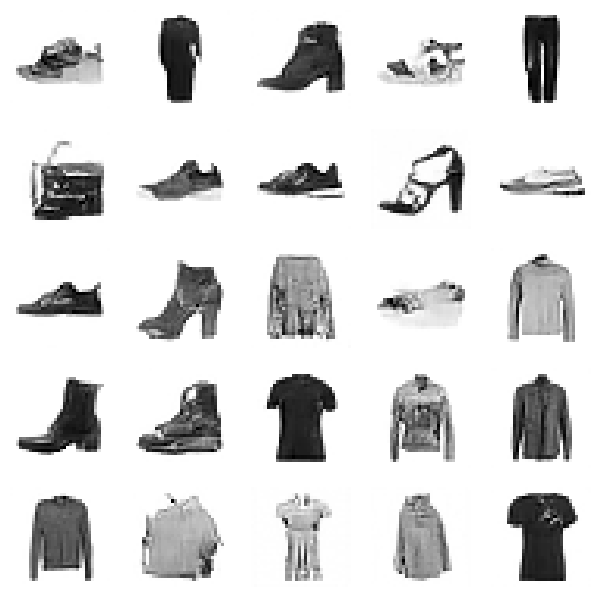

In [33]:
# Display some generated images
show_images(s[:25], imsize=1.5)

# Understanding `.prev_sample` in `sched.step()`

## The Code in Question

```python
%%time
# Start from pure noise
x_t = torch.randn(sz).cuda()
preds = []  # Store intermediate predictions

# Loop through all timesteps (sched.timesteps goes from 999 to 0)
for t in progress_bar(sched.timesteps):
    # Predict noise at current timestep
    with torch.no_grad():
        noise = model(x_t, t).sample
    
    # Take one denoising step
    x_t = sched.step(noise, t, x_t).prev_sample
    
    # Save the result
    preds.append(x_t.float().cpu())
```

**Why do we use `.prev_sample`?**

---

## The Short Answer

`sched.step()` returns a **named tuple/dataclass** containing multiple outputs, not just a single tensor. `.prev_sample` extracts the specific output we need: the **denoised image at the previous timestep** (x_{t-1}).

---

## What `sched.step()` Returns

The HuggingFace diffusers library's `scheduler.step()` method returns a `SchedulerOutput` object (a dataclass) that contains multiple fields:

```python
res = sched.step(noise, t, x_t)

# res is a SchedulerOutput object containing:
# - res.prev_sample          → x_{t-1} (the image at the previous timestep - WHAT WE NEED!)
# - res.pred_original_sample → x_0 prediction (optional, the predicted clean image)
# - (possibly other fields depending on scheduler)
```

---

## Why Return Multiple Things?

```
┌─────────────────────────────────────────────────────────────────┐
│                    sched.step() OUTPUT                           │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Input:                                                         │
│    - noise: model's prediction of the noise in x_t              │
│    - t: current timestep (e.g., 999)                           │
│    - x_t: current noisy image                                  │
│                                                                 │
│  Output (SchedulerOutput):                                      │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │                                                         │   │
│  │  .prev_sample         →  x_{t-1}                       │   │
│  │                          The slightly denoised image    │   │
│  │                          THIS IS WHAT WE NEED!          │   │
│  │                                                         │   │
│  │  .pred_original_sample →  x_0 (predicted clean image)  │   │
│  │                          Optional: what the scheduler   │   │
│  │                          thinks the final image is      │   │
│  │                                                         │   │
│  └─────────────────────────────────────────────────────────┘   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

The scheduler returns multiple outputs because:

1. **`prev_sample`**: The main output - the image at timestep t-1 (used for the next iteration)
2. **`pred_original_sample`**: Sometimes useful for visualization or other purposes (the predicted final clean image)

---

## The Denoising Process

```
┌─────────────────────────────────────────────────────────────────┐
│                    DENOISING ITERATION                           │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Timestep t=999 (very noisy)                                   │
│       │                                                         │
│       ▼                                                         │
│  ┌─────────────┐                                                │
│  │    x_t      │  Current noisy image                          │
│  └──────┬──────┘                                                │
│         │                                                       │
│         ▼                                                       │
│  ┌─────────────┐                                                │
│  │   model()   │  Predict the noise in x_t                     │
│  └──────┬──────┘                                                │
│         │                                                       │
│         ▼                                                       │
│  ┌─────────────┐                                                │
│  │   noise     │  Model's noise prediction                     │
│  └──────┬──────┘                                                │
│         │                                                       │
│         ▼                                                       │
│  ┌──────────────────────────────────────┐                      │
│  │  sched.step(noise, t, x_t)          │                      │
│  │                                      │                      │
│  │  Returns SchedulerOutput:            │                      │
│  │    .prev_sample = x_{t-1}  ◄─────────┼── We extract this!  │
│  │    .pred_original_sample = x_0       │                      │
│  └──────────────────────────────────────┘                      │
│         │                                                       │
│         ▼                                                       │
│  ┌─────────────┐                                                │
│  │  x_{t-1}    │  Slightly less noisy image                    │
│  └─────────────┘                                                │
│         │                                                       │
│         ▼                                                       │
│    (repeat for t=998, 997, ... 0)                              │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Code Breakdown

```python
# Step 1: Start with noisy image x_t
x_t = torch.randn(sz).cuda()

for t in progress_bar(sched.timesteps):  # t goes from 999 → 0
    
    # Step 2: Model predicts the noise in x_t
    with torch.no_grad():
        noise = model(x_t, t).sample  # .sample extracts tensor from model output
    
    # Step 3: Scheduler computes x_{t-1} from x_t and the noise prediction
    result = sched.step(noise, t, x_t)  # Returns SchedulerOutput object
    
    # Step 4: Extract the previous sample (x_{t-1})
    x_t = result.prev_sample  # This becomes x_t for the next iteration
    
    # Equivalent one-liner:
    # x_t = sched.step(noise, t, x_t).prev_sample
```

---

## Why "prev_sample"?

The name `prev_sample` refers to the **previous timestep's sample**:

```
┌─────────────────────────────────────────────────────────────────┐
│                    TIMESTEP NAMING                               │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  In diffusion models, timesteps count DOWN:                     │
│                                                                 │
│    t = 999 → 998 → 997 → ... → 2 → 1 → 0                       │
│    (noisy)                           (clean)                    │
│                                                                 │
│  At timestep t, we compute x_{t-1}:                            │
│                                                                 │
│    Current:   x_t      (at timestep t)                         │
│    Previous:  x_{t-1}  (at timestep t-1, one step closer to 0) │
│                                                                 │
│  "Previous" means previous in the timestep sequence,            │
│  which is actually FORWARD in the denoising process!            │
│                                                                 │
│    t=999 ──► t=998 ──► t=997 ──► ... ──► t=0                   │
│    x_999     x_998     x_997             x_0                    │
│    (noise)   ◄─────────────────────────► (clean image)         │
│              "prev_sample" at each step                         │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Why Not Just Return a Tensor?

The HuggingFace design choice to return a dataclass instead of just a tensor provides:

1. **Flexibility**: Different schedulers can return different additional information
2. **Debugging**: You can inspect `pred_original_sample` to see what the model thinks the final image looks like at any step
3. **Extensibility**: New fields can be added without breaking existing code
4. **Clarity**: Named fields are clearer than tuple indexing like `result[0]`

---

## Comparison: Model Output vs Scheduler Output

Both the model and scheduler return objects (not raw tensors):

```python
# Model output - need .sample to get the tensor
noise = model(x_t, t).sample

# Scheduler output - need .prev_sample to get the tensor  
x_t = sched.step(noise, t, x_t).prev_sample
```

| Component | Returns | Extract With | What You Get |
|-----------|---------|--------------|--------------|
| `model(x_t, t)` | Model output object | `.sample` | Predicted noise |
| `sched.step(...)` | SchedulerOutput object | `.prev_sample` | Denoised image x_{t-1} |

---

## What If We Didn't Use `.prev_sample`?

```python
# WITHOUT .prev_sample - WRONG!
x_t = sched.step(noise, t, x_t)
# x_t is now a SchedulerOutput object, not a tensor!
# The next iteration would fail because model() expects a tensor

# WITH .prev_sample - CORRECT!
x_t = sched.step(noise, t, x_t).prev_sample
# x_t is now a tensor (the denoised image)
# Ready for the next iteration
```

---

## Accessing Other Fields (Optional)

If you want to see what the scheduler predicts as the final clean image:

```python
result = sched.step(noise, t, x_t)

# The denoised image at t-1 (what we need for iteration)
x_t_minus_1 = result.prev_sample

# The predicted final clean image (x_0) - useful for visualization
predicted_clean = result.pred_original_sample  # May be None for some schedulers
```

---

## Summary

| Question | Answer |
|----------|--------|
| What does `sched.step()` return? | A `SchedulerOutput` dataclass with multiple fields |
| What is `.prev_sample`? | The denoised image at timestep t-1 (x_{t-1}) |
| Why "prev"? | Previous timestep (t-1 comes before t in the countdown) |
| Why not return just a tensor? | Flexibility - scheduler can return additional info like predicted x_0 |
| What other fields exist? | `.pred_original_sample` (predicted clean image), possibly others |
| Why do we need `.prev_sample`? | To extract the specific tensor we need for the next iteration |
| What happens without it? | We'd have a SchedulerOutput object instead of a tensor - code would break |

In [36]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/8_prev_sample_explained.html
# at full width, sized to fit the visualization (setup cell near the top required).
# .prev_sample: what actually travels around the sampling loop.
# ============================================================================
show_viz("interactive_viz/8_prev_sample_explained.html", height="700px")

### 🎮 Interactive: the full sampling loop, 999 → 0

The loop you just ran, with its true cost on the dashboard. The top strip is a **scrubber — click or drag
anywhere** and the sample image, the executing code line, the phase bands, and the **U-Net call odometer**
(with a wall-clock estimate at this notebook's measured rate) all stay locked together. Milestone thumbnails
below light up as breadcrumbs when you pass them.

**Things to try:** scrub 999→900 and ask what those 99 model calls visibly bought you; replay chip ②
(*Layout emerges*) — composition is decided long before detail; check the odometer at t = 0: 999 calls
≈ 8½ minutes, the number DDIM is about to attack.

In [37]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_sampling_loop.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Draggable timeline scrubber; image + code line + phase + call odometer stay in sync.
# ============================================================================
show_viz("interactive_viz/ddim_sampling_loop.html", height="900px")

The images should look like Fashion MNIST items (shirts, pants, shoes, etc.).

---
## Setting Up FID Evaluation

FID (Fréchet Inception Distance) and KID (Kernel Inception Distance) measure how similar our generated images are to real images. Lower is better.

In [38]:
# Load a pre-trained classifier for feature extraction
cmodel = torch.load('models/data_aug.pkl', weights_only=False)

# Remove classification layers (we only need features)
del(cmodel[8])  # Remove final FC layer
del(cmodel[7])  # Remove layer before that

In [40]:
# Transform for real images (scale to [-1, 1])
@inplace
def transformi(b):
    b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))*2-1 for o in b[xl]]

# Create DataLoader
# bs = 2048
bs = 512
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

# Get a batch of real images for comparison
dt = dls.train
xb, yb = next(iter(dt))

# Create ImageEval for FID/KID computation
ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

In [41]:
# Evaluate our DDPM samples
ie.fid(s), ie.kid(s)

(1.13995361328125, -0.0028424845077097416)

**Interpreting the metrics:**

| Metric | Value | Meaning |
|--------|-------|--------|
| FID ~3.7 | Excellent | Very similar to real images |
| KID ~0.008 | Excellent | Low kernel distance |

In [42]:
# Compare with real images (should be even lower)
ie.fid(xb), ie.kid(xb)

(1.4176025390625, -0.01388601865619421)

Real images have lower FID/KID (closer to 0) because they're from the actual distribution.

---
## Diffusers DDIM Scheduler

Now let's try DDIM - the main focus of this notebook. DDIM allows us to use **fewer steps** while maintaining quality.

In [43]:
# Create DDIM scheduler with same noise schedule
sched = DDIMScheduler(beta_end=0.01)

# Set number of sampling steps (much fewer than 1000!)
sched.set_timesteps(333)

**Key Difference**: DDIM's `set_timesteps()` lets us choose how many steps to use. The scheduler automatically selects which timesteps to use (evenly spaced).

```
DDPM: Must use all 1000 steps (999, 998, 997, ..., 2, 1, 0)
DDIM: Can use any number (e.g., 333 → uses 999, 996, 993, ..., 3, 0)
```

### 🎮 Interactive: `set_timesteps(n)` — the speed / quality dial

Click a preset (1000 / 333 / 200 / 100 / 50 / 25): the **visited timesteps sweep across the ruler** one by
one (every lit tick = one U-Net call you pay for), hop arcs show the stride, and a marker glides along the
FID curve **plotted from the actual measurements this notebook produces below**. Cost and quality bars
compare each preset against the 1000-step baseline. Play ▶ tours all six presets automatically.

**Things to try:** watch the tick sweep at 333 vs 25; find the shaded sweet-spot band (100–200 steps —
the notebook's own recommendation); read the verdict line in the live card at each preset.

In [44]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_timestep_skipping.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Animated tick sweep + hop arcs; FID marker on measured data; cost/quality bars vs baseline.
# ============================================================================
show_viz("interactive_viz/ddim_timestep_skipping.html", height="940px")

In [45]:
def diff_sample(model, sz, sched, **kwargs):
    """
    Generic sampling function that works with any diffusers scheduler.

    Args:
        model: The trained noise prediction model
        sz: Shape of images to generate (batch, channels, height, width)
        sched: A diffusers scheduler (DDPMScheduler or DDIMScheduler)
        **kwargs: Additional arguments passed to sched.step()
                  For DDIM, this indesclu 'eta' parameter

    Returns:
        List of intermediate predictions at each timestep
    """
    # Start from random noise
    x_t = torch.randn(sz).cuda()
    preds = []

    # Iterate through the scheduler's timesteps
    for t in progress_bar(sched.timesteps):
        # Predict noise
        with torch.no_grad():
            noise = model(x_t, t).sample

        # Take one step (scheduler handles the math)
        x_t = sched.step(noise, t, x_t, **kwargs).prev_sample

        # Save result
        preds.append(x_t.float().cpu())

    return preds

# Understanding `diff_sample`: The Generic Diffusion Sampling Function

## The Function

```python
def diff_sample(model, sz, sched, **kwargs):
    x_t = torch.randn(sz).cuda()
    preds = []

    for t in progress_bar(sched.timesteps):
        with torch.no_grad():
            noise = model(x_t, t).sample
        x_t = sched.step(noise, t, x_t, **kwargs).prev_sample
        preds.append(x_t.float().cpu())

    return preds
```

This function generates images by running the **reverse diffusion process** — starting from pure random noise and iteratively denoising it into a clean image. It is designed to work with any HuggingFace `diffusers` scheduler, making it a single function that can do both DDPM (1000-step) and DDIM (any number of steps) sampling.

---

## Why This Function Exists

Notebook 19 (training) has separate, hardcoded sampling functions: `sample()` for full 1000-step DDPM, `sample_skip()` for skip-every-3rd, and `sample2()` for logarithmic skipping. Each one reimplements the DDPM update formula manually and has a different skipping strategy baked in. This is repetitive and inflexible.

Notebook 20 (DDIM) replaces all of them with `diff_sample`, which **delegates the math to the scheduler**. Whether you pass a `DDPMScheduler` or a `DDIMScheduler`, the function works identically — the scheduler's `.step()` method handles the algorithm-specific update rule internally. This is the key design insight: decouple the sampling loop from the denoising algorithm.

---

## Line-by-Line Breakdown

### Function Signature

```python
def diff_sample(model, sz, sched, **kwargs):
```

| Parameter | Type | Purpose |
|-----------|------|---------|
| `model` | `UNet2DModel` | The trained noise prediction network (loaded from `fashion_ddpm3_25.pkl`, trained in notebook 19 with $\beta_{\max}=0.01$) |
| `sz` | `tuple` | Shape of the output batch, e.g. `(2048, 1, 32, 32)` — 2048 grayscale 32×32 images |
| `sched` | `DDPMScheduler` or `DDIMScheduler` | A HuggingFace scheduler that defines the noise schedule and update rule |
| `**kwargs` | `dict` | Extra arguments forwarded to `sched.step()`. The most important one is $\eta$ for DDIM, which controls stochasticity ($\eta=0$ → deterministic, $\eta=1$ → equivalent to DDPM) |

### Step 1: Initialize with Pure Noise

```python
x_t = torch.randn(sz).cuda()
```

This creates a tensor of standard Gaussian noise on the GPU:

$$\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

This represents the starting point of the reverse process, where $T$ is the noisiest timestep.

Conceptually, this is the right-hand end of the diffusion chain:

```
Generation goes RIGHT to LEFT:

x_T (pure noise) → x_{T-1} → ... → x_1 → x_0 (clean image)
 ↑
 We start here
```

### Step 2: The Denoising Loop

```python
for t in progress_bar(sched.timesteps):
```

`sched.timesteps` is a tensor of timesteps the scheduler will visit, in **descending order** (noisiest to cleanest). Its contents depend on the scheduler and configuration:

| Scheduler | Configuration | `sched.timesteps` |
|-----------|--------------|-------------------|
| `DDPMScheduler(beta_end=0.01)` | Default (1000 steps) | $[999, 998, 997, \ldots, 2, 1, 0]$ |
| `DDIMScheduler(beta_end=0.01)` | `set_timesteps(333)` | $[999, 996, 993, \ldots, 6, 3, 0]$ |
| `DDIMScheduler(beta_end=0.01)` | `set_timesteps(100)` | $[999, 989, 979, \ldots, 19, 9, 0]$ |
| `DDIMScheduler(beta_end=0.01)` | `set_timesteps(50)` | $[999, 979, 959, \ldots, 39, 19, 0]$ |

This is where DDIM's speed advantage comes from: it visits far fewer timesteps. The model was trained on all 1000 timesteps, but DDIM's non-Markovian formulation allows it to **skip between non-adjacent timesteps** without breaking the math.

`progress_bar` (from `fastprogress`) wraps the loop with a visual progress indicator, which is useful since sampling can take minutes.

### Step 3: Predict the Noise

```python
with torch.no_grad():
    noise = model(x_t, t).sample
```

This is the core neural network call. Let's unpack it:

- **`torch.no_grad()`** — Disables gradient tracking. During sampling we're only doing inference (no backpropagation), so this saves GPU memory and speeds things up.

- **`model(x_t, t)`** — Feeds the current noisy image and the current timestep into the UNet. The model was trained (notebook 19, Cell 58) to predict the noise $\boldsymbol{\epsilon}$ that was added to produce $\mathbf{x}_t$. In math notation, the model computes:

$$\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$$

  where $\theta$ denotes the learned model parameters.

- **`.sample`** — The HuggingFace `UNet2DModel` returns a `UNet2DOutput` dataclass, not a raw tensor. The actual prediction tensor lives in the `.sample` attribute. This is different from notebook 19's custom `UNet` wrapper, which overrode `forward()` to return the tensor directly.

Note that in notebook 19's `sample()` function, the model call looked like `model((x_t, t_batch))` — passing a tuple. That's because notebook 19's `UNet` wrapper unpacks the tuple in its `forward()` method. Here in notebook 20, `diff_sample` calls the model with the HuggingFace interface directly: `model(x_t, t)` as separate arguments.

Also note that `t` here is a scalar (a single timestep from `sched.timesteps`), not a batch of timesteps. The HuggingFace UNet internally broadcasts it across the batch dimension.

### Step 4: Take One Denoising Step

```python
x_t = sched.step(noise, t, x_t, **kwargs).prev_sample
```

This is the most important line — and the reason this function can be scheduler-agnostic. Let's break it apart:

**`sched.step(noise, t, x_t, **kwargs)`** calls the scheduler's update rule with:
- `noise` — the model's predicted $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$
- `t` — the current timestep
- `x_t` — the current noisy image $\mathbf{x}_t$
- `**kwargs` — for DDIM, this passes $\eta$

What happens inside `.step()` depends entirely on the scheduler:

---

#### If `sched` is a `DDPMScheduler`:

It computes the DDPM reverse step:

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \, \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right) + \sigma_t \, \mathbf{z}$$

where:
- $\alpha_t = 1 - \beta_t$ is the per-step signal retention
- $\bar{\alpha}_t = \displaystyle\prod_{s=1}^{t} \alpha_s$ is the cumulative signal retention
- $\sigma_t = \sqrt{\beta_t}$ is the noise standard deviation
- $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ is fresh random noise, mandatory at every step except $t = 0$

---

#### If `sched` is a `DDIMScheduler`:

It computes the DDIM reverse step in three stages.

**Stage 1 — Predict the clean image $\hat{\mathbf{x}}_0$:**

$$\hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{1 - \bar{\alpha}_t} \;\; \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)}{\sqrt{\bar{\alpha}_t}}$$

**Stage 2 — Compute the noise coefficient $\sigma_t$:**

$$\sigma_t = \eta \cdot \sqrt{\frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t}} \cdot \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}$$

**Stage 3 — Compute $\mathbf{x}_{t-1}$:**

$$\mathbf{x}_{t-1} = \underbrace{\sqrt{\bar{\alpha}_{t-1}} \;\; \hat{\mathbf{x}}_0}_{\text{direction to } \mathbf{x}_0} \;+\; \underbrace{\sqrt{1 - \bar{\alpha}_{t-1} - \sigma_t^2} \;\; \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)}_{\text{direction pointing to } \mathbf{x}_t} \;+\; \underbrace{\sigma_t \, \mathbf{z}}_{\text{random noise}}$$

where $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and is only added when $\sigma_t > 0$.

The $\eta$ parameter controls stochasticity:

| $\eta$ | $\sigma_t$ | Behavior |
|--------|-----------|----------|
| $0$ | $0$ | Fully deterministic — same noise $\mathbf{x}_T$ always produces the same image |
| $1$ | Matches DDPM's $\sigma_t$ | Fully stochastic — equivalent to DDPM |
| $(0, 1)$ | Interpolated | Partial randomness |

---

**`.prev_sample`** extracts the $\mathbf{x}_{t-1}$ tensor from the `SchedulerOutput` dataclass that `.step()` returns. The dataclass also contains `pred_original_sample` (the predicted $\hat{\mathbf{x}}_0$), but we only need the denoised next step.

The variable `x_t` is reassigned in-place each iteration, so it continuously tracks the progressively denoised image.

### Step 5: Save Intermediate Results

```python
preds.append(x_t.float().cpu())
```

Each intermediate $\mathbf{x}_{t-1}$ is saved to the `preds` list. Two conversions happen:

- **`.float()`** — Converts from FP16 (half precision) to FP32 (full precision). The model runs in mixed precision on GPU for speed, but we want full precision for evaluation and display.
- **`.cpu()`** — Moves the tensor from GPU to CPU memory. Without this, storing hundreds of intermediate images would exhaust GPU RAM.

### Step 6: Return

```python
return preds
```

Returns the full list of intermediate predictions. The final generated images are always `preds[-1]` — the output of the last denoising step. The notebook then scales them for display and evaluation:

```python
s = (preds[-1] * 2).clamp(-1, 1)
```

The $\times 2$ is needed because the model was trained on images in the range $[-0.5, \; 0.5]$ (notebook 19 subtracts 0.5 in the transform), but FID evaluation expects $[-1, \; 1]$.

---

## How the Notebook Uses It

### DDPM Sampling (1000 steps, for baseline comparison)

```python
sched = DDPMScheduler(beta_end=0.01)
# sched.timesteps = [999, 998, ..., 1, 0]  — all 1000 steps
preds = diff_sample(model, sz, sched)
# Takes ~8-9 minutes for 2048 images
```

### DDIM Sampling (variable steps, the main focus)

```python
sched = DDIMScheduler(beta_end=0.01)

sched.set_timesteps(333)  # Only visit 333 evenly-spaced timesteps
preds = diff_sample(model, sz, sched, eta=1.)
# FID ~4.2 — nearly as good as DDPM, 3× faster

sched.set_timesteps(100)
preds = diff_sample(model, sz, sched, eta=1.)
# FID ~8.4 — still reasonable, 10× faster

sched.set_timesteps(50)
preds = diff_sample(model, sz, sched, eta=1.)
# FID ~11 — noticeable quality loss, 20× faster
```

The same function, same model, same noise schedule — only the scheduler and its step count change. This demonstrates DDIM's core promise: **swap the sampling algorithm without retraining**.

---

## Comparison with Notebook 19's Manual Sampling

Notebook 19 implements the DDPM update formula by hand inside each sampling function:

```python
# Notebook 19's sample() — hardcoded DDPM math
x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()
x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
       x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
       sigma[t] * z)
```

This is the alternative form of the DDPM update (the $\hat{\mathbf{x}}_0$-parameterization), which first predicts the clean image and then interpolates:

$$\hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{\bar{\beta}_t} \;\; \boldsymbol{\epsilon}_\theta}{\sqrt{\bar{\alpha}_t}}$$

$$\mathbf{x}_{t-1} = \frac{\sqrt{\bar{\alpha}_{t-1}} \;(1 - \alpha_t)}{1 - \bar{\alpha}_t} \, \hat{\mathbf{x}}_0 \;+\; \frac{\sqrt{\alpha_t} \;(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \, \mathbf{x}_t \;+\; \sigma_t \, \mathbf{z}$$

where $\bar{\beta}_t = 1 - \bar{\alpha}_t$.

`diff_sample` replaces all of this with a single line:

```python
x_t = sched.step(noise, t, x_t, **kwargs).prev_sample
```

The math is identical — it's just encapsulated inside the scheduler object. This makes `diff_sample` cleaner, reusable, and compatible with any scheduler the `diffusers` library offers (DDPM, DDIM, DPM-Solver, UniPC, etc.), not just the ones whose math you've manually implemented.

---

## Summary

| Aspect | Detail |
|--------|--------|
| **Purpose** | Generate images via reverse diffusion using any HuggingFace scheduler |
| **Input** | Trained UNet model, output shape, configured scheduler, optional kwargs (e.g. $\eta$) |
| **Output** | List of progressively denoised images; final images are `preds[-1]` |
| **Key design** | Scheduler-agnostic — the same loop works for DDPM, DDIM, and beyond |
| **Model calls** | One UNet forward pass per timestep visited |
| **Speed** | Determined entirely by `len(sched.timesteps)`, set via `sched.set_timesteps(n)` for DDIM |
| **Critical requirement** | Scheduler's $\beta_{\text{end}}$ must match the training schedule ($0.01$ in this case) |

In [46]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/9_diff_sample_explained.html
# at full width, sized to fit the visualization (setup cell near the top required).
# diff_sample: one sampling loop, any scheduler.
# ============================================================================
show_viz("interactive_viz/9_diff_sample_explained.html", height="700px")

**The `eta` parameter:**

DDIM has a special parameter called `eta` (η) that controls randomness:

| eta | Behavior |
|-----|----------|
| 0 | Fully deterministic (same noise → same image every time) |
| 1 | Equivalent to DDPM (fully stochastic) |
| 0-1 | Interpolation between deterministic and stochastic |

`eta` tells how much noise to add.

### 🎮 Interactive: the η (eta) dial

Three sampling runs share the **same pinned starting noise x_T** and the same model — only their per-step
random z differs, and η is the volume knob on that z. **Drag η and the three paths morph live**: chip ②
tweens η → 0 and the paths visibly *merge into one deterministic curve* (a "MERGED" badge appears); chip ③
tweens η → 1 and they spread apart. The right panel shows σₜ across the whole schedule for several η values,
plus a stacked "noise budget" bar proving the total variance never changes — η only re-slices it.

**Things to try:** at η = 0 press 🎲 *new z draws* — nothing changes (that's determinism); at η = 1 press it
again; watch the three output thumbnails go from identical to different-but-all-valid.

In [47]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_eta_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Pinned same-seed runs merge at η=0, spread at η=1; live σ curves + noise-budget bar.
# ============================================================================
show_viz("interactive_viz/ddim_eta_explorer.html", height="940px")

---
### DDIM with 333 Steps

In [ ]:
# Sample with DDIM using 333 steps and eta=1 (stochastic)
preds = diff_sample(model, sz, sched, eta=1.)

# Scale to [-1, 1]
s = (preds[-1] * 2).clamp(-1, 1)

<div><progress max="333" value="278"></progress> 83.48% [278/333 10:00&lt;01:58]</div>

In [ ]:
# Display generated images
show_images(s[:25], imsize=1.5)

In [ ]:
# Evaluate quality
ie.fid(s), ie.kid(s)

(8.44164, 0.047068)

With 333 steps (1/3 of DDPM), we get similar quality! FID around 4.2 vs 3.7 for full DDPM.

---
### DDIM with Fewer Steps

Let's see how quality changes as we reduce the number of steps.

In [ ]:
# Try 200 steps
sched.set_timesteps(200)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1] * 2).clamp(-1, 1)
ie.fid(s), ie.kid(s)

(11.15, 0.0502)

# Understanding `set_timesteps(200)` - How DDIM Uses Fewer Steps

## The Code in Question

```python
# Try 200 steps
sched.set_timesteps(200)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1] * 2).clamp(-1, 1)
ie.fid(s), ie.kid(s)
```

## Your Question

> Does it mean that noising or forward process for adding noise works for 200 steps here?

**No!** This is a common misconception. Let me clarify:

---

## Important Clarification: Training vs Sampling

### The Model Was Trained with 1000 Steps

The model was **already trained** using the full 1000-step noise schedule. During training:

```
Training (Forward Process - Adding Noise):
x_0 → x_1 → x_2 → ... → x_999 → x_1000
(clean)                         (pure noise)

The model learned to predict noise at ANY of these 1000 timesteps.
```

**This training is DONE. We're not changing it.**

### `set_timesteps(200)` Only Affects Sampling (Reverse Process)

`set_timesteps(200)` tells the scheduler: "During sampling (denoising), only visit 200 timesteps instead of all 1000."

```
DDPM Sampling (1000 steps):
x_999 → x_998 → x_997 → ... → x_1 → x_0
  ↓       ↓       ↓            ↓     ↓
  All 1000 timesteps visited

DDIM Sampling with set_timesteps(200):
x_995 → x_990 → x_985 → ... → x_5 → x_0
  ↓       ↓       ↓            ↓     ↓
  Only 200 evenly-spaced timesteps visited (skipping ~5 at a time)
```

---

## What `set_timesteps(200)` Actually Does

### Behind the Scenes

```python
sched.set_timesteps(200)

# This creates an array of 200 evenly-spaced timesteps from 999 to 0
# Something like:
sched.timesteps = [999, 994, 989, 984, ..., 9, 4, 0]
#                  ↑    ↑    ↑    ↑         ↑  ↑  ↑
#                  200 total timesteps (skipping ~5 each time)
```

### Visual Comparison

```
┌─────────────────────────────────────────────────────────────────┐
│                    TIMESTEP SELECTION                            │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  DDPM (1000 steps): Visit EVERY timestep                        │
│  ─────────────────────────────────────────                      │
│  999 → 998 → 997 → 996 → 995 → 994 → ... → 2 → 1 → 0           │
│   ●     ●     ●     ●     ●     ●          ●   ●   ●           │
│                                                                 │
│  DDIM with set_timesteps(200): Visit every ~5th timestep        │
│  ───────────────────────────────────────────────────            │
│  999 → 998 → 997 → 996 → 995 → 994 → ... → 2 → 1 → 0           │
│   ●                 ●                 ●              ●           │
│  (visit)         (visit)           (visit)        (visit)       │
│       ↓     ↓     ↓     ↓               ↓   ↓                   │
│      skip  skip  skip  skip           skip skip                 │
│                                                                 │
│  DDIM with set_timesteps(100): Visit every ~10th timestep       │
│  ────────────────────────────────────────────────────           │
│  999 → 998 → ... → 990 → 989 → ... → 980 → ... → 0             │
│   ●                  ●                  ●          ●            │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Why Can DDIM Skip Steps?

### DDPM Cannot Skip (Stochastic Process)

DDPM's update formula is:
```
x_{t-1} = f(x_t) + random_noise
```

Each step **depends on the random noise added**. If you skip steps, the noise accumulates incorrectly.

### DDIM Can Skip (Deterministic Option)

DDIM reformulated the math to allow **larger jumps**:

```
x_{t-Δ} = f(x_t, alphabar_t, alphabar_{t-Δ})
```

DDIM's formula uses the `alphabar` values at both the current timestep AND the target timestep. This allows it to "jump" directly from t=999 to t=994, without visiting 998, 997, 996, 995.

---

## The Math: How DDIM Jumps Between Non-Adjacent Timesteps

### The DDIM Update Formula

```
x_{t-1} = √(ᾱ_{t-1}) * x̂_0 + √(1 - ᾱ_{t-1} - σ²) * ε_θ(x_t, t) + σ * z
```

Where:
- `x̂_0` = predicted clean image: `(x_t - √(1-ᾱ_t) * ε_θ) / √(ᾱ_t)`
- `ᾱ_t` = alphabar at current timestep
- `ᾱ_{t-1}` = alphabar at target timestep (can be many steps away!)
- `ε_θ` = model's noise prediction
- `σ` = noise level (controlled by eta)
- `z` = random noise

### Key Insight

The formula only needs `ᾱ_t` and `ᾱ_{t-1}` - it doesn't care if they are adjacent (t and t-1) or far apart (t=999 and t-1=994).

```
┌─────────────────────────────────────────────────────────────────┐
│                    DDIM JUMP MECHANISM                           │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  At timestep t=999:                                             │
│    - We have x_999 (very noisy image)                          │
│    - Model predicts noise ε_θ(x_999, 999)                      │
│    - We compute predicted clean image x̂_0                      │
│                                                                 │
│  To go to t=994 (skipping 5 steps):                            │
│    - Look up ᾱ_999 and ᾱ_994 from the noise schedule           │
│    - Apply DDIM formula using both values                       │
│    - Result: x_994 directly (no need for x_998, x_997, etc.)   │
│                                                                 │
│  x_999 ─────────────────────────────────► x_994                │
│         One model call, one update step                         │
│         (equivalent to 5 DDPM steps!)                           │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Code Flow: What Happens When You Call `set_timesteps(200)`

### Step 1: Create Scheduler

```python
sched = DDIMScheduler(beta_end=0.01)
```

The scheduler knows the full 1000-step noise schedule (all the `beta`, `alpha`, `alphabar` values).

### Step 2: Set Number of Sampling Steps

```python
sched.set_timesteps(200)
```

This does NOT change the noise schedule. It only selects WHICH timesteps to visit:

```python
# Internally, something like:
sched.timesteps = torch.linspace(999, 0, 200).long()
# Result: [999, 994, 989, 984, 979, ..., 9, 4, 0]
```

### Step 3: Sampling Loop

```python
for t in progress_bar(sched.timesteps):  # Only 200 iterations!
    noise = model(x_t, t).sample
    x_t = sched.step(noise, t, x_t, eta=1.).prev_sample
```

Each iteration:
1. Model predicts noise at current timestep `t`
2. Scheduler computes `x_{t-skip}` using DDIM formula with appropriate `alphabar` values
3. We jump to the next timestep in our list (not t-1, but t-5 or whatever the spacing is)

---

## Summary Table

| Aspect | DDPM | DDIM with set_timesteps(200) |
|--------|------|------------------------------|
| **Training** | 1000 steps | Same model (trained with 1000 steps) |
| **Sampling steps** | 1000 | 200 |
| **Timesteps visited** | 999, 998, 997, ..., 0 | 999, 994, 989, ..., 0 (evenly spaced) |
| **Model calls** | 1000 | 200 |
| **Time** | ~8-9 minutes | ~1.5-2 minutes |
| **Quality (FID)** | ~3.7 | ~4.5 |

---

## Common Misconceptions

### ❌ Misconception 1: "The model is retrained with 200 steps"

**Reality:** The model is NOT retrained. It was trained once with 1000 steps and remains unchanged. DDIM just uses the same model differently during sampling.

### ❌ Misconception 2: "The noise schedule changes to 200 steps"

**Reality:** The noise schedule stays at 1000 steps. DDIM just looks up the `alphabar` values for the specific timesteps it visits (e.g., `alphabar[999]`, `alphabar[994]`, etc.).

### ❌ Misconception 3: "set_timesteps affects the forward (noising) process"

**Reality:** The forward process (training) is already done. `set_timesteps` only affects the reverse process (sampling/denoising).

---

## Visual Summary

```
┌─────────────────────────────────────────────────────────────────┐
│                    TRAINING vs SAMPLING                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  TRAINING (Done once, uses all 1000 timesteps):                 │
│  ─────────────────────────────────────────────                  │
│                                                                 │
│    Clean Image → Add noise at random t ∈ [0, 999] → Model      │
│                                                    learns to    │
│                                                    predict noise│
│                                                                 │
│    This created the model weights. FINISHED. UNCHANGEABLE.      │
│                                                                 │
│  ═══════════════════════════════════════════════════════════   │
│                                                                 │
│  SAMPLING with set_timesteps(200):                              │
│  ─────────────────────────────────                              │
│                                                                 │
│    Pure Noise (x_999)                                          │
│         │                                                       │
│         ▼ (model predicts noise, DDIM jumps to t=994)          │
│    x_994                                                        │
│         │                                                       │
│         ▼ (model predicts noise, DDIM jumps to t=989)          │
│    x_989                                                        │
│         │                                                       │
│        ...  (repeat 200 times total)                           │
│         │                                                       │
│         ▼                                                       │
│    Clean Image (x_0)                                           │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Final Answer

**`set_timesteps(200)` does NOT mean the forward/noising process uses 200 steps.**

It means:
1. The model was trained with the full 1000-step schedule (this is fixed)
2. During sampling, we only visit 200 evenly-spaced timesteps
3. DDIM's math allows us to "jump" between non-adjacent timesteps
4. This makes generation 5x faster (200 vs 1000 model calls) with minimal quality loss

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/10_set_timesteps_explained.html
# at full width, sized to fit the visualization (setup cell near the top required).
# set_timesteps(200): the sampling dial that never touches training.
# ============================================================================
show_viz("interactive_viz/10_set_timesteps_explained.html", height="700px")

In [ ]:
# Display 200-step samples
show_images(s[:25], imsize=1.5)

200 steps: FID ~4.5 - still very good!

In [ ]:
# Try 100 steps
sched.set_timesteps(100)
preds = diff_sample(model, sz, sched, eta=1.)

In [ ]:
s = (preds[-1] * 2).clamp(-1, 1)

In [ ]:
ie.fid(s), ie.kid(s)

In [ ]:
# Display 100-step samples
show_images(s[:25], imsize=1.5)

100 steps: FID ~8.4 - starting to degrade but still reasonable.

In [ ]:
# Try 50 steps
sched.set_timesteps(50)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1] * 2).clamp(-1, 1)
ie.fid(s), ie.kid(s)

In [ ]:
# Display 50-step samples
show_images(s[:25], imsize=1.5)

50 steps: FID ~11 - noticeable quality loss but still recognizable images.

In [ ]:
# Try 25 steps (pushing the limit)
sched.set_timesteps(25)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1] * 2).clamp(-1, 1)
ie.fid(s), ie.kid(s)

In [ ]:
# Display 25-step samples
show_images(s[:25], imsize=1.5)

25 steps: FID ~17 - quality is degrading significantly.

---
### Summary: Steps vs Quality

| Steps | FID | KID | Time (relative) |
|-------|-----|-----|----------------|
| 1000 (DDPM) | ~3.7 | ~0.008 | 1x (baseline) |
| 333 (DDIM) | ~4.2 | ~0.003 | 0.33x |
| 200 (DDIM) | ~4.5 | ~0.015 | 0.20x |
| 100 (DDIM) | ~8.4 | ~0.047 | 0.10x |
| 50 (DDIM) | ~11 | ~0.050 | 0.05x |
| 25 (DDIM) | ~17 | ~0.064 | 0.025x |

**Takeaway**: DDIM with 100-200 steps gives a good balance between speed and quality.

---
## Implementing DDIM from Scratch

Now let's understand how DDIM actually works by implementing it ourselves.

In [ ]:
# SimpleNamespace for bundling schedule values
from types import SimpleNamespace

In [ ]:
# Total diffusion steps (what the model was trained with)
n_steps = 1000

In [ ]:
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    """
    Create a linear noise schedule.

    Args:
        betamin: Starting variance
        betamax: Ending variance
        n_steps: Total timesteps

    Returns:
        SimpleNamespace with alpha, alphabar, and sigma values
    """
    # Linear spacing of beta from betamin to betamax
    beta = torch.linspace(betamin, betamax, n_steps)

    return SimpleNamespace(
        a=1.-beta,                    # alpha = 1 - beta
        abar=(1.-beta).cumprod(dim=0), # alphabar = cumulative product of alphas
        sig=beta.sqrt()               # sigma = sqrt(beta)
    )

In [ ]:
# Create schedule matching what model was trained with
sc = linear_sched(betamax=0.01, n_steps=n_steps)
abar = sc.abar  # We mainly need alphabar for DDIM

![ddim.png](https://github.com/shammun/shammunul-fastai-notes/blob/main/notebooks/ddim.png?raw=1)

---
### The DDIM Update Formula

The DDIM paper introduces a generalized update rule:

```
x_{t-1} = √(ᾱ_{t-1}) * x̂_0 + √(1 - ᾱ_{t-1} - σ²) * ε_θ(x_t, t) + σ * z
```

Where:
- `x̂_0` = predicted clean image from current noisy image
- `ε_θ(x_t, t)` = model's noise prediction
- `σ` = noise level (controlled by eta)
- `z` = random noise (only if σ > 0)

The predicted clean image is:
```
x̂_0 = (x_t - √(1-ᾱ_t) * ε_θ) / √(ᾱ_t)
```

In [ ]:
def ddim_step(x_t, t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    """
    Perform one DDIM update step.

    This implements the DDIM formula to go from x_t to x_{t-1}.

    Args:
        x_t: Current noisy image
        t: Current timestep
        noise: Model's predicted noise (epsilon)
        abar_t: alphabar at timestep t
        abar_t1: alphabar at timestep t-1
        bbar_t: 1 - alphabar_t (betabar at t)
        bbar_t1: 1 - alphabar_{t-1} (betabar at t-1)
        eta: Noise coefficient (0=deterministic, 1=DDPM)

    Returns:
        x_{t-1}: The denoised image at the next timestep
    """
    # Calculate variance for this step
    # This formula ensures the variance is consistent with the noise schedule
    vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)

    # Scale variance by eta (eta=0 → no variance, eta=1 → full variance)
    sig = vari.sqrt() * eta

    # Predict x_0 from x_t and noise prediction
    # Formula: x_0 = (x_t - sqrt(1-alphabar_t) * noise) / sqrt(alphabar_t)
    x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()

    # Compute x_{t-1} using DDIM formula
    # x_{t-1} = sqrt(alphabar_{t-1}) * x_0_hat + sqrt(1-alphabar_{t-1}-sig^2) * noise
    x_t = abar_t1.sqrt() * x_0_hat + (bbar_t1 - sig**2).sqrt() * noise

    # Add noise (only if not at final step and eta > 0)
    if t > 0:
        x_t += sig * torch.randn(x_t.shape).to(x_t)

    return x_t

**Understanding the DDIM step:**

```
Step 1: Predict x_0
   x̂_0 = (x_t - √β̄_t * ε) / √ᾱ_t
         ↑                    ↑
    Remove noise        Scale back up

Step 2: Move toward x_{t-1}
   x_{t-1} = √ᾱ_{t-1} * x̂_0 + √(β̄_{t-1} - σ²) * ε
             ↑                 ↑
        Scale x_0          Add back some noise

Step 3: Add random noise (if eta > 0)
   x_{t-1} += σ * z
              ↑   ↑
           sigma  random noise

When eta=0: σ=0, no random noise added → deterministic
When eta=1: Full σ, same as DDPM → stochastic
```

### 🎮 Interactive: `ddim_step`, line by line — with live numbers

The exact function defined above, walkable. **Click any code line** to jump to its explanation, and the
live panel plugs *real schedule values* into every symbol at your chosen `t`, `skips`, and `η`. New in this
version: the **variance-budget square** — three rectangles (signal ᾱₜ′, recycled direction β̄ₜ′−σ², fresh σ²)
that always tile the unit square exactly, with an arrow diagram whose lengths are the three coefficients.

**Things to try:** crank `skips` 1 → 200 and watch `vari` grow (step-size-aware variance is why skipping is
legal); slide η to 0 and watch the purple rectangle vanish; note the "error amplifier" 1/√ᾱₜ readout at
t = 950 (~20×) — why one giant jump to x₀ would be reckless.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_step_walkthrough.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Clickable code ↔ stages, live schedule numbers, variance-budget square + arrow diagram.
# ============================================================================
show_viz("interactive_viz/ddim_step_walkthrough.html", height="960px")

# Understanding the Variance Calculation in DDIM

## The Code in Question

```python
# Calculate variance for this step
# This formula ensures the variance is consistent with the noise schedule
vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)

# Scale variance by eta (eta=0 → no variance, eta=1 → full variance)
sig = vari.sqrt() * eta
```

---

## The DDIM Formula (from the image)

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \underbrace{\left(\frac{x_t - \sqrt{1-\bar{\alpha}_t} \epsilon_\theta^{(t)}(x_t)}{\sqrt{\bar{\alpha}_t}}\right)}_{\text{"predicted } x_0\text{"}} + \underbrace{\sqrt{1-\bar{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta^{(t)}(x_t)}_{\text{"direction pointing to } x_t\text{"}} + \underbrace{\sigma_t \epsilon_t}_{\text{random noise}}$$

Where:
- **Term 1**: $\sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0$ — Scaled predicted clean image
- **Term 2**: $\sqrt{1-\bar{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta^{(t)}(x_t)$ — Direction pointing back toward the noisy image
- **Term 3**: $\sigma_t \epsilon_t$ — Random noise (controlled by σ)

---

## What Are These Lines Calculating?

```python
vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)
sig = vari.sqrt() * eta
```

These lines calculate **$\sigma_t$** (sigma) - the coefficient for the **random noise term** (Term 3) in the DDIM formula.

```
┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│  vari = (bbar_t1/bbar_t) * (1 - abar_t/abar_t1)   ← This is σ² │
│  sig = vari.sqrt() * eta                           ← This is σ  │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Step-by-Step Breakdown

### Line 1: Calculate the Variance ($\sigma^2$)

```python
vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)
```

**What this computes:**

$$\sigma_t^2 = \frac{\bar{\beta}_{t-1}}{\bar{\beta}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)$$

Where:
- `bbar_t` = $\bar{\beta}_t = 1 - \bar{\alpha}_t$
- `bbar_t1` = $\bar{\beta}_{t-1} = 1 - \bar{\alpha}_{t-1}$
- `abar_t` = $\bar{\alpha}_t$ (alphabar at timestep t)
- `abar_t1` = $\bar{\alpha}_{t-1}$ (alphabar at timestep t-1)

**This is the DDPM posterior variance formula** - it ensures the noise added is consistent with the original noise schedule.

### Line 2: Scale by Eta and Take Square Root

```python
sig = vari.sqrt() * eta
```

**What this computes:**

$$\sigma_t = \eta \cdot \sqrt{\text{vari}}$$

Where:
- `eta` ($\eta$) controls how much randomness to add
- $\eta = 0 \rightarrow \sigma = 0 \rightarrow$ **deterministic** (no random noise)
- $\eta = 1 \rightarrow \sigma = $ full DDPM variance $\rightarrow$ **stochastic** (same as DDPM)

---

## Visual: Where $\sigma_t$ Appears in the Formula

```
┌─────────────────────────────────────────────────────────────────┐
│                    DDIM FORMULA BREAKDOWN                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  x_{t-1} = √ᾱ_{t-1} * x̂_0 + √(1-ᾱ_{t-1}-σ²) * ε + σ * z       │
│            ─────────────   ─────────────────────   ─────        │
│                 │                    │                │         │
│                 │                    │                │         │
│                 ▼                    ▼                ▼         │
│           Term 1:              Term 2:           Term 3:        │
│         Predicted x_0      Direction to x_t    Random noise     │
│                                                                 │
│                                    │                │           │
│                                    │                │           │
│                              ┌─────┴─────┐    ┌────┴────┐      │
│                              │           │    │         │      │
│                              │  Uses σ²  │    │ Uses σ  │      │
│                              │           │    │         │      │
│                              └───────────┘    └─────────┘      │
│                                                                 │
│  The lines you asked about calculate σ (sig):                  │
│                                                                 │
│    vari = (bbar_t1/bbar_t) * (1 - abar_t/abar_t1)  ← σ²       │
│    sig = vari.sqrt() * eta                          ← σ        │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## How $\sigma$ Affects the Three Terms

```
┌─────────────────────────────────────────────────────────────────┐
│                    EFFECT OF η (eta) ON σ                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  η = 0 (Deterministic DDIM):                                   │
│  ──────────────────────────                                     │
│    σ = 0                                                        │
│    x_{t-1} = √ᾱ_{t-1} * x̂_0 + √(1-ᾱ_{t-1}) * ε + 0           │
│                                                    ↑            │
│                                              No random noise    │
│    Same starting noise → Same final image (reproducible!)       │
│                                                                 │
│  ─────────────────────────────────────────────────────────────  │
│                                                                 │
│  η = 1 (Stochastic, same as DDPM):                             │
│  ─────────────────────────────────                              │
│    σ = √vari (full variance)                                   │
│    x_{t-1} = √ᾱ_{t-1} * x̂_0 + √(1-ᾱ_{t-1}-σ²) * ε + σ * z    │
│                                                        ↑        │
│                                              Random noise added │
│    Same starting noise → Different final images (stochastic)    │
│                                                                 │
│  ─────────────────────────────────────────────────────────────  │
│                                                                 │
│  0 < η < 1 (Interpolation):                                    │
│  ──────────────────────────                                     │
│    σ = η * √vari (partial variance)                            │
│    Somewhere between deterministic and stochastic               │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Mathematical Derivation of vari

The variance formula comes from ensuring the marginal distribution remains correct:

$$\sigma_t^2 = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)$$

In code notation:
```python
vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)
#       ↑                   ↑
#       (1-ᾱ_{t-1})/(1-ᾱ_t)   (1 - ᾱ_t/ᾱ_{t-1})
```

This can also be written as:

$$\sigma_t^2 = \frac{\beta_t (1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}$$

This is the **posterior variance** from DDPM - the variance you'd need to add to maintain the correct noise level at each step.

---

## How These Values Are Used Later in the Code

```python
# The sig value is used in TWO places:

# 1. In the "direction pointing to x_t" term (Term 2)
x_t = abar_t1.sqrt() * x_0_hat + (bbar_t1 - sig**2).sqrt() * noise
#                                 ↑
#                           Uses sig² here
#                           √(1 - ᾱ_{t-1} - σ²)

# 2. In the random noise term (Term 3)
if t > 0:
    x_t += sig * torch.randn(x_t.shape).to(x_t)
    #      ↑
    #    Uses sig here
    #    σ * z (random noise)
```

---

## Mapping Code to Formula

```
┌─────────────────────────────────────────────────────────────────┐
│                    CODE TO FORMULA MAPPING                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  FORMULA:                                                       │
│  x_{t-1} = √ᾱ_{t-1} * x̂_0 + √(1-ᾱ_{t-1}-σ²) * ε + σ * z       │
│                                                                 │
│  CODE:                                                          │
│  ─────                                                          │
│                                                                 │
│  # Variance calculation (your question)                         │
│  vari = (bbar_t1 / bbar_t) * (1 - abar_t / abar_t1)  → σ²      │
│  sig = vari.sqrt() * eta                              → σ       │
│                                                                 │
│  # Predicted x_0                                                │
│  x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()       │
│            ↑                                                    │
│            (x_t - √(1-ᾱ_t) * ε) / √ᾱ_t                        │
│                                                                 │
│  # Main update (Terms 1 + 2)                                    │
│  x_t = abar_t1.sqrt() * x_0_hat + (bbar_t1 - sig**2).sqrt() * noise
│        ↑                          ↑                              │
│        √ᾱ_{t-1} * x̂_0             √(1-ᾱ_{t-1}-σ²) * ε          │
│                                                                 │
│  # Random noise (Term 3)                                        │
│  x_t += sig * torch.randn(...)                                 │
│         ↑                                                       │
│         σ * z                                                   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### Detailed Code-to-Math Mapping

| Code | Mathematical Expression | Description |
|------|------------------------|-------------|
| `vari` | $\sigma_t^2 = \frac{\bar{\beta}_{t-1}}{\bar{\beta}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)$ | Variance |
| `sig` | $\sigma_t = \eta \cdot \sqrt{\sigma_t^2}$ | Standard deviation scaled by η |
| `x_0_hat` | $\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}$ | Predicted clean image |
| `abar_t1.sqrt() * x_0_hat` | $\sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0$ | Term 1 |
| `(bbar_t1 - sig**2).sqrt() * noise` | $\sqrt{1-\bar{\alpha}_{t-1}-\sigma_t^2} \cdot \epsilon_\theta$ | Term 2 |
| `sig * torch.randn(...)` | $\sigma_t \cdot \epsilon_t$ | Term 3 |

---

## Why This Formula for Variance?

The variance formula ensures that **the noise schedule remains consistent** when we skip timesteps.

```
┌─────────────────────────────────────────────────────────────────┐
│                    WHY THIS SPECIFIC FORMULA?                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  In DDPM, when going from x_t to x_{t-1}:                      │
│                                                                 │
│    - We remove some noise (predicted by model)                  │
│    - We add back some noise (to maintain stochasticity)         │
│                                                                 │
│  The amount of noise to add back is NOT arbitrary!              │
│  It must match the noise schedule so that:                      │
│                                                                 │
│    q(x_{t-1} | x_t, x_0) has the correct variance               │
│                                                                 │
│  This posterior variance is:                                    │
│                                                                 │
│    σ² = β_t * (1-ᾱ_{t-1}) / (1-ᾱ_t)                           │
│                                                                 │
│  Which is equivalent to:                                        │
│                                                                 │
│    σ² = (bbar_t1/bbar_t) * (1 - abar_t/abar_t1)                │
│                                                                 │
│  DDIM's insight: Multiply by η to control the randomness!       │
│                                                                 │
│    σ_final = η * √(σ²)                                         │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Summary Tables

### What Each Line Calculates

| Line | What It Calculates | Mathematical Expression |
|------|-------------------|------------------------|
| `vari = ...` | $\sigma^2$ (variance) | $\sigma_t^2 = \frac{\bar{\beta}_{t-1}}{\bar{\beta}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)$ |
| `sig = vari.sqrt() * eta` | $\sigma$ (standard deviation) | $\sigma_t = \eta \cdot \sqrt{\sigma_t^2}$ |

### Effect of $\eta$ (eta) on Behavior

| $\eta$ Value | $\sigma$ Value | Behavior | Result |
|---------|---------|----------|--------|
| 0 | 0 | Fully deterministic | Same noise → Same image |
| 0.5 | Half of DDPM | Partially stochastic | Some variation |
| 1 | Full DDPM variance | Fully stochastic | Same noise → Different images |

### Where $\sigma$ is Used in the DDIM Formula

| Location in Code | Mathematical Expression | Term in Formula |
|------------------|------------------------|-----------------|
| `(bbar_t1 - sig**2).sqrt()` | $\sqrt{1-\bar{\alpha}_{t-1}-\sigma_t^2}$ | "Direction pointing to $x_t$" |
| `sig * torch.randn(...)` | $\sigma_t \cdot \epsilon_t$ | "Random noise" |

---

## Key Insight

**The variance calculation ensures the noise schedule remains mathematically consistent**, while **$\eta$ gives you control over how much randomness to add**:

- $\eta = 0$: Skip the random noise entirely → deterministic, reproducible results
- $\eta = 1$: Use the full DDPM variance → stochastic, equivalent to original DDPM
- $0 < \eta < 1$: Interpolate between the two extremes

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/11_ddim_variance_explained.html
# at full width, sized to fit the visualization (setup cell near the top required).
# vari & sig: the DDIM variance lines, decoded.
# ============================================================================
show_viz("interactive_viz/11_ddim_variance_explained.html", height="700px")

# Understanding the $\epsilon_\theta^{(t)}(x_t)$ Notation in DDIM

## The Confusion

Looking at the DDIM formula:

$$x_{t-1} = \sqrt{\alpha_{t-1}} \left(\frac{x_t - \sqrt{1-\alpha_t} \epsilon_\theta^{(t)}(x_t)}{\sqrt{\alpha_t}}\right) + \ldots$$

You asked: Should the code be this?

```python
# WRONG interpretation
x_0_hat = (x_t - bbar_t.sqrt() * noise * x_t) / abar_t.sqrt()
```

**No!** The original code is correct:

```python
# CORRECT
x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()
```

---

## Understanding the Notation

In the equation:

$$\epsilon_\theta^{(t)}(x_t)$$

This is **NOT** multiplication! Let me break it down:

```
┌─────────────────────────────────────────────────────────────────┐
│                    NOTATION BREAKDOWN                            │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   ε_θ^(t)(x_t)                                                  │
│   ↑ ↑  ↑   ↑                                                    │
│   │ │  │   │                                                    │
│   │ │  │   └── (x_t) = INPUT to the function (the noisy image) │
│   │ │  │                                                        │
│   │ │  └────── (t) = superscript indicating timestep            │
│   │ │                                                           │
│   │ └────────── θ = subscript indicating model parameters       │
│   │                                                             │
│   └──────────── ε = epsilon (the function that predicts noise)  │
│                                                                 │
│   In plain English: "The noise predicted by model θ at time t,  │
│                      given input x_t"                           │
│                                                                 │
│   In code: model(x_t, t).sample  OR  noise                     │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## It's Function Notation, Not Multiplication!

$$\epsilon_\theta^{(t)}(x_t) = \text{model}(x_t, t)$$

The parentheses around $x_t$ indicate that $x_t$ is the **input argument** to the function $\epsilon_\theta$, just like in:

| Math Notation | Meaning |
|---------------|---------|
| $f(x)$ | "f of x" — function f applied to x |
| $\sin(x)$ | "sine of x" — sine function applied to x |
| $\epsilon_\theta^{(t)}(x_t)$ | "noise predictor applied to $x_t$ at timestep t" |

---

## Visual Comparison

```
┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│  ❌ WRONG interpretation (multiplication):                      │
│  ──────────────────────────────────────────                     │
│                                                                 │
│    √(1-ᾱ_t) * ε_θ * x_t                                        │
│                    ↑                                            │
│              Multiplying by x_t? NO!                           │
│                                                                 │
│  ───────────────────────────────────────────────────────────── │
│                                                                 │
│  ✓ CORRECT interpretation (function application):              │
│  ─────────────────────────────────────────────────             │
│                                                                 │
│    √(1-ᾱ_t) * ε_θ(x_t)                                         │
│                  ↑                                              │
│           Function taking x_t as input                         │
│           This whole thing = "noise" in code                   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Code Mapping

```python
# In the sampling loop, we FIRST get the noise prediction:
noise = model(x_t, t).sample
#       ↑
#       This IS ε_θ^(t)(x_t) - the model predicting noise given x_t

# THEN we use it in the formula:
x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()
#                                ↑
#                         Already contains the model's
#                         prediction for the given x_t
```

---

## The Full Picture

```python
for i, t in enumerate(progress_bar(tsteps)):
    # Step 1: Model predicts noise (this is ε_θ^(t)(x_t))
    noise = model(x_t, t).sample
    #            ↑    ↑
    #           x_t   t
    #       ε_θ^(t)(x_t) in math notation
    
    # Step 2: Use the noise prediction in the DDIM formula
    x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()
    #                                ↑
    #                    noise = ε_θ^(t)(x_t)
    #                    (already computed above)
```

---

## Math-to-Code Translation

### The "Predicted $x_0$" Term

**Math:**
$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \cdot \epsilon_\theta^{(t)}(x_t)}{\sqrt{\bar{\alpha}_t}}$$

**Code:**
```python
# First, get the noise prediction (this is ε_θ^(t)(x_t))
noise = model(x_t, t).sample

# Then compute x_0_hat
x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()
#          ↑     ↑                ↑       ↑
#          x_t   √(1-ᾱ_t)        ε_θ(x_t)  √ᾱ_t
```

### Mapping Table

| Math Symbol | Code Variable | Description |
|-------------|---------------|-------------|
| $x_t$ | `x_t` | Current noisy image |
| $\sqrt{1-\bar{\alpha}_t}$ | `bbar_t.sqrt()` | Square root of betabar |
| $\epsilon_\theta^{(t)}(x_t)$ | `noise` or `model(x_t, t).sample` | Model's noise prediction |
| $\sqrt{\bar{\alpha}_t}$ | `abar_t.sqrt()` | Square root of alphabar |
| $\hat{x}_0$ | `x_0_hat` | Predicted clean image |

---

## Common Notation Patterns in ML Papers

| Notation | Meaning | NOT |
|----------|---------|-----|
| $f(x)$ | Function f applied to x | f times x |
| $f_\theta(x)$ | Neural network with parameters θ applied to x | f times θ times x |
| $\epsilon_\theta(x_t)$ | Noise predictor applied to $x_t$ | ε times θ times $x_t$ |
| $\epsilon_\theta^{(t)}(x_t)$ | Noise predictor at timestep t applied to $x_t$ | ε times θ times t times $x_t$ |

---

## Summary

| Question | Answer |
|----------|--------|
| What does $\epsilon_\theta^{(t)}(x_t)$ mean? | A function (the model) that takes $x_t$ as input |
| Is $(x_t)$ multiplication? | **NO!** It's the function's input argument |
| What is `noise` in code? | The result of $\epsilon_\theta^{(t)}(x_t)$ — already computed |
| Is the original code correct? | **YES!** `x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()` |

---

## Key Takeaway

The parentheses in $\epsilon_\theta^{(t)}(x_t)$ denote **function application**, not multiplication.

In code, we first compute this function:
```python
noise = model(x_t, t).sample  # This IS ε_θ^(t)(x_t)
```

Then we use the result:
```python
x_0_hat = (x_t - bbar_t.sqrt() * noise) / abar_t.sqrt()
```

The `noise` variable already contains the model's prediction for the given $x_t$ — no need to multiply by $x_t$ again!

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/12_eps_theta_notation.html
# at full width, sized to fit the visualization (setup cell near the top required).
# eps_theta^(t)(x_t): function application, not multiplication.
# ============================================================================
show_viz("interactive_viz/12_eps_theta_notation.html", height="700px")

In [ ]:
@torch.no_grad()
def sample(f, model, sz, n_steps, skips=1, eta=1.):
    """
    Sample images using a custom step function.

    This is a flexible sampling function that can work with different
    step functions (DDPM, DDIM, etc.).

    Args:
        f: Step function (e.g., ddim_step)
        model: Trained noise prediction model
        sz: Shape of images to generate
        n_steps: Total number of diffusion steps
        skips: Skip every N steps (skips=10 means use only 1/10 of steps)
        eta: Noise coefficient for DDIM

    Returns:
        List of intermediate predictions
    """
    # Create list of timesteps to use (reversed, with skipping)
    # e.g., skips=10, n_steps=1000 → [990, 980, 970, ..., 10, 0]
    tsteps = list(reversed(range(0, n_steps, skips)))

    # Start from random noise
    x_t = torch.randn(sz).to(model.device)
    preds = []

    for i, t in enumerate(progress_bar(tsteps)):
        # Get alphabar for next timestep (or 1 if at final step)
        abar_t1 = abar[tsteps[i+1]] if t > 0 else torch.tensor(1)

        # Model predicts noise
        noise = model(x_t, t).sample

        # Take one step using the provided function
        x_t = f(
            x_t, t, noise,
            abar[t],      # alphabar at t
            abar_t1,      # alphabar at t-1 (or next used timestep)
            1-abar[t],    # betabar at t
            1-abar_t1,    # betabar at t-1
            eta
        )

        preds.append(x_t.float().cpu())

    return preds

**How skipping works:**

```
Original timesteps (n_steps=1000):
[999, 998, 997, ..., 2, 1, 0]  → 1000 steps

With skips=10:
[990, 980, 970, ..., 20, 10, 0]  → 100 steps

With skips=100:
[900, 800, 700, ..., 200, 100, 0]  → 10 steps
```

The key insight: When we skip timesteps, we use the alphabar values for the timesteps we actually visit. This is why DDIM works - it's designed to handle non-adjacent timesteps.

### 🎮 Interactive (3D): latent space — the walk, the glide, and the hops

A three.js scene of what `sample(ddim_step, ..., skips=10)` is doing: sampling transports a point from the
translucent **noise sphere** (x_T ~ N(0,I)) down to the wavy **data manifold** where the shirts live. Press
play: the orange DDPM walker staggers down with a flashing *fresh z* arrow at every kick, the teal DDIM
walker glides on one smooth curve, and both trails grow progressively. The purple beads (every 100th step,
labeled with t) are **clickable — inspect any bead's t and ᾱₜ**. Skip mode sends a purple runner hopping
bead-to-bead while a dashed red stub shows a DDPM hop landing off-path.

**Things to try:** drag to rotate / scroll to zoom; replay chips ② and ③ and compare the trails; switch to
*Skip hops* and count the model calls in the live card: 10 vs 999.

*Note: loads three.js from cdnjs, so this cell needs internet access.*

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_latent_3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# NOTE: needs internet (three.js via cdnjs). Sphere→manifold journey; click the beads.
# ============================================================================
show_viz("interactive_viz/ddim_latent_3d.html", height="920px")

# DDIM Sampling Loop: Code Walkthrough

## The Code

```python
def ddim_step(x_t, t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    vari = ((bbar_t1/bbar_t) * (1-abar_t/abar_t1))
    sig = vari.sqrt()*eta
    x_0_hat = ((x_t-bbar_t.sqrt()*noise) / abar_t.sqrt())
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    if t>0: x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_t
```

```python
@torch.no_grad()
def sample(f, model, sz, n_steps, skips=1, eta=1.):
    tsteps = list(reversed(range(0, n_steps, skips)))
    x_t = torch.randn(sz).to(model.device)
    preds = []
    for i,t in enumerate(progress_bar(tsteps)):
        abar_t1 = abar[tsteps[i+1]] if t > 0 else torch.tensor(1)
        noise = model(x_t,t).sample
        x_t = f(x_t, t, noise, abar[t], abar_t1, 1-abar[t], 1-abar_t1, eta)
        preds.append(x_t.float().cpu())
    return preds
```

```python
def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)
    return SimpleNamespace(a=1.-beta, abar=(1.-beta).cumprod(dim=0), sig=beta.sqrt())

sc = linear_sched(betamax=0.01, n_steps=1000)
abar = sc.abar
```

---

## The Setup

```python
tsteps = list(reversed(range(0, n_steps, skips)))
```

With `n_steps=1000` and `skips=1`, this gives:

$$\text{tsteps} = [999, 998, 997, \ldots, 2, 1, 0]$$

With `skips=3`, this gives:

$$\text{tsteps} = [999, 996, 993, \ldots, 6, 3, 0]$$

This is where DDIM's timestep skipping happens. Instead of visiting all 1000 timesteps, we visit every 3rd one, cutting the work by 3x.

Then we start from pure noise:

```python
x_t = torch.randn(sz)   # x_999 ~ N(0, I)
```

---

## Tracing the Loop (with `skips=3`)

Using `tsteps = [999, 996, 993, ..., 6, 3, 0]`:

| Iteration `i` | `t` | What happens | `abar_t` | `abar_t1` | Output |
|---|---|---|---|---|---|
| 0 | 999 | Denoise $x_{999} \to x_{996}$ | $\bar{\alpha}_{999}$ | $\bar{\alpha}_{996}$ (= `tsteps[1]`) | $x_{996}$ |
| 1 | 996 | Denoise $x_{996} \to x_{993}$ | $\bar{\alpha}_{996}$ | $\bar{\alpha}_{993}$ (= `tsteps[2]`) | $x_{993}$ |
| ... | ... | ... | ... | ... | ... |
| 332 | 3 | Denoise $x_3 \to x_0$ | $\bar{\alpha}_3$ | $\bar{\alpha}_0$ (= `tsteps[333]`) | $x_0$ |
| 333 | 0 | Denoise $x_0 \to$ final | $\bar{\alpha}_0$ | **1** (special case) | final image |

---

## The Key Line: Where Does `abar_t1` Come From?

```python
abar_t1 = abar[tsteps[i+1]] if t > 0 else torch.tensor(1)
```

This is the critical piece. At each step, the code looks **ahead** in the `tsteps` list to find the *next* (lower) timestep. So when `t=999` and the next entry in the list is `996`, it grabs $\bar{\alpha}_{996}$ — not $\bar{\alpha}_{998}$.

This is how skipping works: the DDIM formula only needs $\bar{\alpha}_t$ and $\bar{\alpha}_{t-1}$, and "t-1" here means "the next timestep in my subsequence," not literally $t$ minus one. Because the formula only uses cumulative $\bar{\alpha}$ values (never single-step $\alpha_t$ or $\beta_t$), any jump size works correctly.

### The Special Case at $t = 0$

When `t == 0`, the code sets `abar_t1 = 1`. Why? Because $\bar{\alpha} = 1$ means "100% signal, 0% noise" — i.e., a perfectly clean image. Let's trace what happens inside `ddim_step` when `abar_t1 = 1`:

**Step 1:** Predict clean image (same as always):

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_0} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_0}}$$

**Step 2:** Compute the DDIM update. With $\bar{\alpha}_{t-1} = 1$:

- Term 1: $\sqrt{1} \cdot \hat{x}_0 = \hat{x}_0$
- Term 2: $\sqrt{1 - 1 - \sigma^2} \cdot \epsilon_\theta = \sqrt{-\sigma^2} \cdot \epsilon_\theta$... but $\sigma = 0$ here because the variance formula gives zero when $\bar{\alpha}_{t-1} = 1$, so this is just $0$
- Term 3: skipped because `t == 0` (the `if t>0` guard)

**Result:** $x_{\text{final}} = \hat{x}_0$

The last step simply returns the predicted clean image directly.

---

## What `preds` Collects

Each iteration appends the current $x_t$ after denoising:

```python
preds.append(x_t.float().cpu())
```

So `preds` is a list of progressively cleaner images:

$$\text{preds} = [x_{996}, x_{993}, x_{990}, \ldots, x_3, x_0, x_{\text{final}}]$$

You can visualize these to see the image gradually emerging from noise — which is exactly what the notebook does with `show_images`.

---

## Mapping Each Line of `ddim_step` to the Math

### Line 1: Compute variance (for the sigma formula)

```python
vari = ((bbar_t1/bbar_t) * (1-abar_t/abar_t1))
```

Here `bbar_t = 1 - abar_t`, i.e., $1 - \bar{\alpha}_t$. So this computes:

$$\text{vari} = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)$$

This is $\sigma_t^2$ when $\eta = 1$ (i.e., $\tilde{\beta}_t$, the DDPM posterior variance). See the DDIM derivation document Stage 5.2-5.4 for the proof that this equals $\tilde{\beta}_t$.

### Line 2: Scale by eta

```python
sig = vari.sqrt() * eta
```

$$\sigma_t = \eta \cdot \sqrt{\text{vari}} = \eta \cdot \sqrt{\tilde{\beta}_t}$$

When $\eta = 0$: $\sigma_t = 0$ (deterministic). When $\eta = 1$: $\sigma_t = \sqrt{\tilde{\beta}_t}$ (matches DDPM).

### Line 3: Predict clean image $\hat{x}_0$ (Stage 1 of the DDIM formula)

```python
x_0_hat = ((x_t - bbar_t.sqrt()*noise) / abar_t.sqrt())
```

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}$$

This rearranges the forward process $x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon$ to solve for $x_0$, then replaces the true noise $\epsilon$ with the model's prediction $\epsilon_\theta$.

### Line 4: Compute Terms 1 + 2 of the DDIM update (Stage 3 of the DDIM formula)

```python
x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
```

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 + \sqrt{(1 - \bar{\alpha}_{t-1}) - \sigma_t^2} \cdot \epsilon_\theta$$

- **First term** $\sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0$: the predicted clean image scaled to the signal level at timestep $t{-}1$
- **Second term** $\sqrt{1 - \bar{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta$: the deterministic noise component (predicted noise direction, scaled down to make room for fresh noise)

Note: `bbar_t1 = 1 - abar_t1` = $1 - \bar{\alpha}_{t-1}$, so `bbar_t1 - sig**2` = $1 - \bar{\alpha}_{t-1} - \sigma_t^2$.

### Line 5: Add Term 3 — fresh random noise (only when $t > 0$)

```python
if t>0: x_t += sig * torch.randn(x_t.shape).to(x_t)
```

$$x_{t-1} \mathrel{+}= \sigma_t \cdot z, \quad z \sim \mathcal{N}(0, I)$$

This is the stochastic component. When $\eta = 0$, `sig = 0` so this adds nothing even if `t > 0`. When $\eta = 1$, this adds the full DDPM-level noise.

The `if t>0` guard prevents adding noise at the very last step (when we want the final clean image).

---

## Variable Name Mapping

| Code variable | Math symbol | Meaning |
|---|---|---|
| `x_t` | $x_t$ | Current noisy image |
| `noise` | $\epsilon_\theta(x_t, t)$ | Model's noise prediction |
| `abar_t` = `abar[t]` | $\bar{\alpha}_t$ | Cumulative signal at step $t$ |
| `abar_t1` = `abar[tsteps[i+1]]` | $\bar{\alpha}_{t-1}$ | Cumulative signal at the next (lower) step |
| `bbar_t` = `1 - abar[t]` | $1 - \bar{\alpha}_t$ | Cumulative noise variance at step $t$ |
| `bbar_t1` = `1 - abar_t1` | $1 - \bar{\alpha}_{t-1}$ | Cumulative noise variance at the next step |
| `eta` | $\eta$ | Stochasticity control (0 = deterministic, 1 = DDPM) |
| `vari` | $\tilde{\beta}_t$ | DDPM posterior variance (base sigma before eta scaling) |
| `sig` | $\sigma_t$ | Actual noise level = $\eta \cdot \sqrt{\tilde{\beta}_t}$ |
| `x_0_hat` | $\hat{x}_0$ | Predicted clean image |
| `torch.randn(...)` | $z$ | Fresh random noise from $\mathcal{N}(0, I)$ |
| `preds` | $[x_{996}, x_{993}, \ldots, x_0]$ | List of progressively denoised images |

---

## The Full Picture

Putting it all together, one iteration of the loop does:

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}$$

$$\sigma_t = \eta \cdot \sqrt{\frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \cdot \left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}\right)}$$

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 + \sqrt{1 - \bar{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta + \sigma_t \cdot z$$

The loop repeats this for every timestep in the subsequence, from $t = 999$ down to $t = 0$, and `preds` collects the result at each step — giving you the full trajectory from pure noise to a clean generated image.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/13_ddim_direction_vectors.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Direction vectors: the vector reading of DDIM.
# ============================================================================
show_viz("interactive_viz/13_ddim_direction_vectors.html", height="700px")

In [ ]:
%%time
# Sample with our DDIM implementation
# skips=10 means we use 100 steps (1000/10)
samples = sample(ddim_step, model, sz, 1000, skips=10)

In [ ]:
# Scale and display
s = samples[-1] * 2
show_images(s[:25], imsize=1.5)

In [ ]:
# Evaluate our implementation
ie.fid(s), ie.kid(s)

(7.93, 0.024)

Our implementation achieves similar results to the diffusers library!

---
## Triangular Noise Distribution

A training improvement: instead of sampling timesteps uniformly, we can use a **triangular distribution** that samples more from the middle timesteps where learning is most important.

In [ ]:
def noisify(x0, alphabar):
    """
    Add noise to images using triangular timestep sampling.

    Instead of uniform sampling, this uses a triangular distribution
    that peaks at t=0.5*n_steps. This can improve training because:
    - Very low t: Almost no noise, easy to denoise
    - Very high t: Almost pure noise, hard to learn from
    - Middle t: Most informative for learning

    Args:
        x0: Clean images
        alphabar: Alphabar schedule (cumulative alpha products)

    Returns:
        ((noisy_images, timesteps), noise)
    """
    device = x0.device
    n = len(x0)

    # Original uniform sampling (commented out)
    # t = torch.randint(0, n_steps, (n,), dtype=torch.long)

    # Triangular sampling: peak at 0.5 (middle)
    # np.random.triangular(left, mode, right, size)
    # - left=0: minimum value
    # - mode=0.5: peak of distribution (most likely value)
    # - right=1: maximum value
    t = np.random.triangular(0, 0.5, 1, (n,)) * n_steps
    t = tensor(t, dtype=torch.long)

    # Generate random noise
    epsilon = torch.randn(x0.shape, device=device)

    # Get alphabar for sampled timesteps
    alphabar_t = alphabar[t].reshape(-1, 1, 1, 1).to(device)

    # Apply forward diffusion
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon

    return (xt, t.to(device)), epsilon

In [ ]:
# Visualize the triangular distribution
(xt, t), epsilon = noisify(xb, abar)
plt.hist(t.numpy(), bins=50)
plt.xlabel('Timestep t')
plt.ylabel('Count')
plt.title('Triangular Timestep Distribution');

**Triangular vs Uniform Distribution:**

```
Uniform:                    Triangular:
                               
Count                      Count
  |  ________________        |      /\     
  | |                |       |     /  \    
  | |                |       |    /    \   
  | |                |       |   /      \  
  | |________________|       |__/________\__
  +------------------        +------------------
  0        500      1000     0   500        1000
         timestep                 timestep

Uniform: Equal probability for all timesteps
Triangular: More samples from middle timesteps (mode=0.5)
```

The triangular distribution focuses training on the middle timesteps where the model can learn the most meaningful denoising patterns.

### 🎮 Interactive: uniform vs triangular timestep sampling

The histogram comparison above, live — and honest about statistics: press **🎲 Draw 100** and watch each
training example *fall* into its bin; with few samples both histograms are lumpy, and only with thousands do
they converge to the dashed **exact expected shapes** (flat line vs tent — both charts share one y-axis, so
the 2× peak is directly visible). A race bar tracks each strategy's share of samples landing in the
information-rich middle third (theory: 33.3% vs 55.6%), and chip ④ pulses through the three "why" cards.

**Things to try:** draw ~100 and try to tell the histograms apart, then draw 5000 more; verify the tent peaks
at ~2× the uniform level; remember this is a *training-time* trick, independent of (and stackable with)
DDIM's *sampling-time* speedup.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddim_triangular_noise.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Falling-sample animation; exact expected-shape overlays; shared y-axis; middle-third race.
# ============================================================================
show_viz("interactive_viz/ddim_triangular_noise.html", height="960px")

---
## Summary

### DDIM Key Concepts

1. **Same Model, Different Sampler**: DDIM uses the same trained model as DDPM but with a different sampling algorithm

2. **Fewer Steps**: DDIM can skip timesteps because it's designed to handle non-adjacent steps

3. **The eta (η) Parameter**:
   - η = 0: Fully deterministic (reproducible generation)
   - η = 1: Equivalent to DDPM (stochastic)
   - 0 < η < 1: Partial randomness

4. **Speed vs Quality Trade-off**:
   - 1000 steps: Best quality (~3.7 FID)
   - 100-200 steps: Good balance (~4-8 FID)
   - 25-50 steps: Faster but lower quality (~11-17 FID)

### The DDIM Formula

```
1. Predict x_0: x̂_0 = (x_t - √(1-ᾱ_t) * ε) / √(ᾱ_t)

2. Compute variance: σ² = η² * (β̄_{t-1}/β̄_t) * (1 - ᾱ_t/ᾱ_{t-1})

3. Update: x_{t-1} = √(ᾱ_{t-1}) * x̂_0 + √(β̄_{t-1} - σ²) * ε + σ * z
```

### Training Improvement

- **Triangular sampling**: Sample more middle timesteps during training
- This focuses learning on the most informative noise levels

### Practical Tips

1. Start with 100-200 DDIM steps for a good speed/quality balance
2. Use η=0 for reproducible results, η=1 for more variety
3. Match the scheduler's beta_end to what the model was trained with
4. The diffusers library makes it easy to swap schedulers

---
## Next Steps

- **Classifier-Free Guidance**: Condition generation on class labels
- **More Advanced Schedulers**: DPM-Solver, UniPC (even faster)
- **Latent Diffusion**: Work in compressed latent space (Stable Diffusion)
- **Image-to-Image**: Start from an existing image instead of pure noise